# DATA01 Executive Search Analytics Assignment

## Notebook 01: Datenimport, Debitor-Feature-Matrix, Debitor-EDA und erste Cluster-Baseline

Dieses Notebook lädt die bereinigte Analysebasis, prüft die wichtigsten Grundannahmen und erzeugt eine Debitor-Feature-Matrix. Anschließend folgen eine gezielte Debitor-EDA, fachlich begründete Cleaning-Regeln, ein bewusst schlankes Feature Engineering sowie eine überarbeitete Baseline für die erste Clusteranalyse.


In [746]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [747]:
file_path = "../data/raw/UDB - 2010 - 2025 - prep - complete.xlsx"
df = pd.read_excel(file_path)

print("Zeilen:", df.shape[0])
print("Spalten:", df.shape[1])

Zeilen: 15262
Spalten: 14


In [748]:
df.columns.tolist()

['ID',
 'Datum',
 'Rechnungsnummer',
 'Vertragsart',
 'Umsatzart',
 'Umsatzart_Sub',
 'Jobkategorie',
 'Branche',
 'Debitor',
 'Netto_Betrag_Indexed',
 'Nebenkosten_Indexed',
 'Placement',
 'OTE',
 'Fuehrungsposition']

In [749]:
df.head()

,ID,Datum,Rechnungsnummer,Vertragsart,Umsatzart,Umsatzart_Sub,Jobkategorie,Branche,Debitor,Netto_Betrag_Indexed,Nebenkosten_Indexed,Placement,OTE,Fuehrungsposition
0,854,2010-08-09,E-PCVII-10-7036,Prozent - 3 Raten,1 Personalberatung,Start,Spezialist (Kerngeschäft),Industrial,Debitor 377,0.051282,0.0,False,NaN,False
1,860,2010-08-12,E-PCII-10-2001,Prozent - 3 Raten,1 Personalberatung,Start,C-Level,Industrial,Debitor 547,0.055556,0.0,False,NaN,False
2,861,2010-08-12,E-PCI-10-1085,Pauschalhonorar,1 Personalberatung,Erfolgsauftrag,C-Level,Digital & Technology,Debitor 419,0.235043,0.0,True,NaN,False
3,862,2010-08-13,E-PCI-10-1086,Prozent - 3 Raten,1 Personalberatung,Start,Vertrieb/Presales/Marketing,Digital & Technology,Debitor 185,0.056974,0.0,False,NaN,False
4,863,2010-08-13,E-PCI-10-1087,Prozent - 3 Raten,1 Personalberatung,Start,Vertrieb/Presales/Marketing,Digital & Technology,Debitor 185,0.056974,0.0,False,NaN,False


In [750]:
# Datumsfeld in ein konsistentes Format überführen

df["Datum"] = pd.to_datetime(df["Datum"], errors="coerce")

print("Frühestes Datum:", df["Datum"].min())
print("Spätestes Datum:", df["Datum"].max())
print("Fehlende Datumswerte:", df["Datum"].isna().sum())

Frühestes Datum: 2010-01-04 00:00:00
Spätestes Datum: 2025-12-31 00:00:00
Fehlende Datumswerte: 0


In [751]:
print("Placement:")
print(df["Placement"].value_counts(dropna=False))
print()

print("Fuehrungsposition:")
print(df["Fuehrungsposition"].value_counts(dropna=False))

Placement:
Placement
False    11373
True      3889
Name: count, dtype: int64

Fuehrungsposition:
Fuehrungsposition
False    12230
True      3032
Name: count, dtype: int64


In [752]:
def get_mode(series):
    series = series.dropna().astype(str).str.strip()
    if series.empty:
        return np.nan
    return series.mode().iloc[0]


def count_distinct(series):
    series = series.dropna().astype(str).str.strip()
    series = series[series != ""]
    return series.nunique()

In [753]:
# Debitor-Feature-Matrix aufbauen

debitor_features = df.groupby("Debitor").agg(
    invoice_count=("Rechnungsnummer", "nunique"),
    first_invoice_date=("Datum", "min"),
    last_invoice_date=("Datum", "max"),
    active_years_count=("Datum", lambda x: x.dt.year.nunique()),
    net_index_sum=("Netto_Betrag_Indexed", "sum"),
    net_index_mean=("Netto_Betrag_Indexed", "mean"),
    nk_index_sum=("Nebenkosten_Indexed", "sum"),
    nk_index_mean=("Nebenkosten_Indexed", "mean"),
    placement_count=("Placement", lambda x: x.fillna(False).sum()),
    placement_rate=("Placement", lambda x: x.fillna(False).mean()),
    leadership_count=("Fuehrungsposition", lambda x: x.fillna(False).sum()),
    leadership_rate=("Fuehrungsposition", lambda x: x.fillna(False).mean()),
    dominant_contract_type=("Vertragsart", get_mode),
    dominant_revenue_subtype=("Umsatzart_Sub", get_mode),
    dominant_job_category=("Jobkategorie", get_mode),
    dominant_industry=("Branche", get_mode),
    contract_type_nunique=("Vertragsart", count_distinct),
    revenue_subtype_nunique=("Umsatzart_Sub", count_distinct),
    job_category_nunique=("Jobkategorie", count_distinct),
    industry_nunique=("Branche", count_distinct)
).reset_index()

In [754]:
# Zusätzliche Zeitmerkmale ergänzen

debitor_features["active_days"] = (
    debitor_features["last_invoice_date"] - debitor_features["first_invoice_date"]
).dt.days

analysis_date = pd.Timestamp("2025-12-31")

debitor_features["recency_days"] = (
    analysis_date - debitor_features["last_invoice_date"]
).dt.days

In [755]:
print("Anzahl Debitoren:", debitor_features.shape[0])
print("Anzahl Features:", debitor_features.shape[1])

Anzahl Debitoren: 1364
Anzahl Features: 23


In [756]:
debitor_features.head()

,Debitor,invoice_count,first_invoice_date,last_invoice_date,active_years_count,net_index_sum,net_index_mean,nk_index_sum,nk_index_mean,placement_count,...,dominant_contract_type,dominant_revenue_subtype,dominant_job_category,dominant_industry,contract_type_nunique,revenue_subtype_nunique,job_category_nunique,industry_nunique,active_days,recency_days
0,Debitor 1,101,2010-11-25,2025-11-27,16,5.974359,0.059152,0.581197,0.005754,30,...,Pauschal - 3 Raten,Start,Spezialist (Kerngeschäft),Digital & Technology,3,8,2,2,5481,34
1,Debitor 10,1,2018-11-27,2018-11-27,1,0.042735,0.042735,0.000000,0.000000,1,...,Pauschalhonorar,Erfolgsauftrag,Spezialist (Kerngeschäft),Digital & Technology,1,1,1,1,0,2591
2,Debitor 100,36,2017-11-15,2025-09-26,7,2.910427,0.080845,0.338704,0.009408,9,...,Prozent - 3 Raten,Start,Spezialist (Kerngeschäft),Financial Services,2,4,4,2,2872,96
3,Debitor 1000,2,2012-10-31,2013-03-21,2,0.153846,0.076923,0.002564,0.001282,1,...,Prozent mit Anzahlung,Abschluss,Vertrieb/Presales/Marketing,Digital & Technology,1,2,1,1,141,4668
4,Debitor 1001,4,2011-07-28,2011-11-15,1,0.307692,0.076923,0.000000,0.000000,0,...,Prozent - 3 Raten,Präsentation,C-Level,Financial Services,1,2,2,1,110,5160


In [757]:
# Erste Plausibilitätsprüfung zentraler numerischer Merkmale

debitor_features[
    [
        "invoice_count",
        "active_years_count",
        "net_index_sum",
        "placement_count",
        "placement_rate",
        "leadership_rate",
        "active_days",
        "recency_days",
        "contract_type_nunique",
        "revenue_subtype_nunique",
        "job_category_nunique",
        "industry_nunique"
    ]
].describe().round(3)

,invoice_count,active_years_count,net_index_sum,placement_count,placement_rate,leadership_rate,active_days,recency_days,contract_type_nunique,revenue_subtype_nunique,job_category_nunique,industry_nunique
count,1364.000,1364.000,1364.000,1364.000,1364.000,1364.000,1364.000,1364.000,1364.000,1364.000,1364.000,1364.000
mean,11.143,2.390,0.919,2.851,0.231,0.259,727.979,2092.298,1.600,3.433,1.679,1.173
std,20.704,1.951,1.562,5.882,0.206,0.378,1086.895,1673.240,0.997,1.815,0.981,0.467
min,0.000,1.000,-0.071,0.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000,1.000
25%,3.000,1.000,0.199,0.000,0.000,0.000,89.000,649.750,1.000,2.000,1.000,1.000
50%,5.000,2.000,0.413,1.000,0.231,0.000,260.000,1645.000,1.000,3.000,1.000,1.000
75%,11.000,3.000,0.971,3.000,0.333,0.500,854.000,3360.500,2.000,4.000,2.000,1.000
max,257.000,16.000,18.944,72.000,1.000,1.000,5712.000,5826.000,7.000,12.000,7.000,5.000


## Debitor-EDA

Im nächsten Schritt wird die Debitor-Matrix knapp, aber gezielt geprüft. Der Fokus liegt auf Fehlwerten, Verteilungen und auffälligen Fällen, die für das weitere Data Cleaning relevant sind.

In [758]:
eda_df = debitor_features.copy()

print("Anzahl Debitoren:", eda_df.shape[0])
print("Anzahl Features:", eda_df.shape[1])

Anzahl Debitoren: 1364
Anzahl Features: 23


In [759]:
# Struktur und Datentypen

print("Spalten:")
print(eda_df.columns.tolist())
print()
print("Datentypen:")
print(eda_df.dtypes)

Spalten:
['Debitor', 'invoice_count', 'first_invoice_date', 'last_invoice_date', 'active_years_count', 'net_index_sum', 'net_index_mean', 'nk_index_sum', 'nk_index_mean', 'placement_count', 'placement_rate', 'leadership_count', 'leadership_rate', 'dominant_contract_type', 'dominant_revenue_subtype', 'dominant_job_category', 'dominant_industry', 'contract_type_nunique', 'revenue_subtype_nunique', 'job_category_nunique', 'industry_nunique', 'active_days', 'recency_days']

Datentypen:
Debitor                                str
invoice_count                        int64
first_invoice_date          datetime64[us]
last_invoice_date           datetime64[us]
active_years_count                   int64
net_index_sum                      float64
net_index_mean                     float64
nk_index_sum                       float64
nk_index_mean                      float64
placement_count                      int64
placement_rate                     float64
leadership_count                     int

In [760]:
# Fehlwerte je Feature

missing_summary = pd.DataFrame({
    "missing_count": eda_df.isna().sum(),
    "missing_pct": (eda_df.isna().sum() / len(eda_df) * 100).round(2)
}).sort_values(["missing_count", "missing_pct"], ascending=False)

missing_summary

,missing_count,missing_pct
Debitor,0,0.0
invoice_count,0,0.0
first_invoice_date,0,0.0
last_invoice_date,0,0.0
active_years_count,0,0.0
net_index_sum,0,0.0
net_index_mean,0,0.0
nk_index_sum,0,0.0
nk_index_mean,0,0.0
placement_count,0,0.0


In [761]:
# Konstante und fast konstante Features

unique_summary = pd.DataFrame({
    "n_unique": eda_df.nunique(dropna=False)
}).sort_values("n_unique")

unique_summary

,n_unique
industry_nunique,5
dominant_job_category,7
contract_type_nunique,7
job_category_nunique,7
dominant_industry,9
dominant_contract_type,10
revenue_subtype_nunique,12
active_years_count,15
dominant_revenue_subtype,18
leadership_count,31


In [762]:
# Numerische und kategoriale Features trennen

numeric_cols = eda_df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = eda_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numerische Features:")
print(numeric_cols)
print()
print("Kategoriale Features:")
print(categorical_cols)

Numerische Features:
['invoice_count', 'active_years_count', 'net_index_sum', 'net_index_mean', 'nk_index_sum', 'nk_index_mean', 'placement_count', 'placement_rate', 'leadership_count', 'leadership_rate', 'contract_type_nunique', 'revenue_subtype_nunique', 'job_category_nunique', 'industry_nunique', 'active_days', 'recency_days']

Kategoriale Features:
['Debitor', 'dominant_contract_type', 'dominant_revenue_subtype', 'dominant_job_category', 'dominant_industry']


C:\Users\jensm\AppData\Local\Temp\ipykernel_33416\3578270278.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = eda_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


In [763]:
# Deskriptive Statistik für numerische Features

numeric_summary = eda_df[numeric_cols].describe().T
numeric_summary["median"] = eda_df[numeric_cols].median()
numeric_summary["missing_count"] = eda_df[numeric_cols].isna().sum()
numeric_summary["missing_pct"] = (eda_df[numeric_cols].isna().sum() / len(eda_df) * 100).round(2)

numeric_summary

,count,mean,std,min,25%,50%,75%,max,median,missing_count,missing_pct
invoice_count,1364.0,11.142962,20.704310,0.000000,3.000000,5.000000,11.000000,257.000000,5.000000,0,0.0
active_years_count,1364.0,2.390029,1.950695,1.000000,1.000000,2.000000,3.000000,16.000000,2.000000,0,0.0
net_index_sum,1364.0,0.918982,1.561713,-0.071368,0.198611,0.413085,0.971474,18.944017,0.413085,0,0.0
net_index_mean,1364.0,0.089626,0.053661,-0.035684,0.059829,0.077550,0.106838,0.854701,0.077550,0,0.0
nk_index_sum,1364.0,0.052232,0.110286,-0.002082,0.000000,0.018786,0.051282,1.777778,0.018786,0,0.0
nk_index_mean,1364.0,0.005752,0.007302,-0.000045,0.000000,0.003921,0.008547,0.066667,0.003921,0,0.0
placement_count,1364.0,2.851173,5.882363,0.000000,0.000000,1.000000,3.000000,72.000000,1.000000,0,0.0
placement_rate,1364.0,0.231396,0.206170,0.000000,0.000000,0.230769,0.333333,1.000000,0.230769,0,0.0
leadership_count,1364.0,2.222874,4.651639,0.000000,0.000000,0.000000,3.000000,65.000000,0.000000,0,0.0
leadership_rate,1364.0,0.259176,0.377950,0.000000,0.000000,0.000000,0.500000,1.000000,0.000000,0,0.0


In [764]:
# Auffällige Fälle gezielt prüfen

invoice_zero_df = eda_df[eda_df["invoice_count"] == 0]
negative_net_df = eda_df[eda_df["net_index_sum"] < 0]
negative_nk_df = eda_df[eda_df["nk_index_sum"] < 0]

print("Debitoren mit invoice_count = 0:", len(invoice_zero_df))
print("Debitoren mit negativem net_index_sum:", len(negative_net_df))
print("Debitoren mit negativem nk_index_sum:", len(negative_nk_df))

Debitoren mit invoice_count = 0: 1
Debitoren mit negativem net_index_sum: 1
Debitoren mit negativem nk_index_sum: 1


In [765]:
invoice_zero_df.head(10)

,Debitor,invoice_count,first_invoice_date,last_invoice_date,active_years_count,net_index_sum,net_index_mean,nk_index_sum,nk_index_mean,placement_count,...,dominant_contract_type,dominant_revenue_subtype,dominant_job_category,dominant_industry,contract_type_nunique,revenue_subtype_nunique,job_category_nunique,industry_nunique,active_days,recency_days
312,Debitor 128,0,2012-03-06,2012-03-06,1,0.0,0.0,0.0,0.0,1,...,N/V,Replacement,Corporate Services,Professional Services,1,1,1,1,0,5048


In [766]:
negative_net_df.head(10)

,Debitor,invoice_count,first_invoice_date,last_invoice_date,active_years_count,net_index_sum,net_index_mean,nk_index_sum,nk_index_mean,placement_count,...,dominant_contract_type,dominant_revenue_subtype,dominant_job_category,dominant_industry,contract_type_nunique,revenue_subtype_nunique,job_category_nunique,industry_nunique,active_days,recency_days
663,Debitor 368,2,2010-06-11,2010-06-11,1,-0.071368,-0.035684,0.0,0.0,0,...,Prozent mit Anzahlung,Abbruch,C-Level,Industrial,1,1,2,1,0,5682


In [767]:
negative_nk_df.head(10)

,Debitor,invoice_count,first_invoice_date,last_invoice_date,active_years_count,net_index_sum,net_index_mean,nk_index_sum,nk_index_mean,placement_count,...,dominant_contract_type,dominant_revenue_subtype,dominant_job_category,dominant_industry,contract_type_nunique,revenue_subtype_nunique,job_category_nunique,industry_nunique,active_days,recency_days
259,Debitor 1231,46,2013-12-30,2022-10-19,10,1.675676,0.036428,-0.002082,-0.000045,10,...,Pauschal - 3 Raten,Start,C-Level,Professional Services,5,10,4,3,3215,1169


In [768]:
# Null-Anteile in numerischen Features

zero_summary = []

for col in numeric_cols:
    zero_count = (eda_df[col] == 0).sum()
    zero_pct = round(zero_count / len(eda_df) * 100, 2)
    zero_summary.append({
        "feature": col,
        "zero_count": zero_count,
        "zero_pct": zero_pct
    })

zero_summary_df = pd.DataFrame(zero_summary).sort_values("zero_pct", ascending=False)
zero_summary_df

,feature,zero_count,zero_pct
9,leadership_rate,781,57.26
8,leadership_count,781,57.26
5,nk_index_mean,469,34.38
4,nk_index_sum,469,34.38
7,placement_rate,380,27.86
6,placement_count,380,27.86
14,active_days,134,9.82
15,recency_days,18,1.32
3,net_index_mean,16,1.17
2,net_index_sum,16,1.17


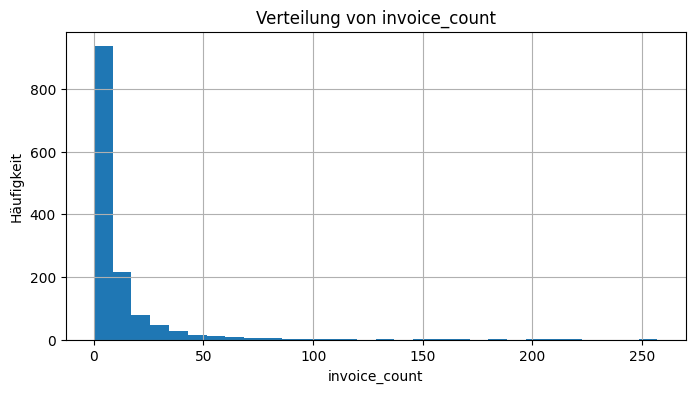

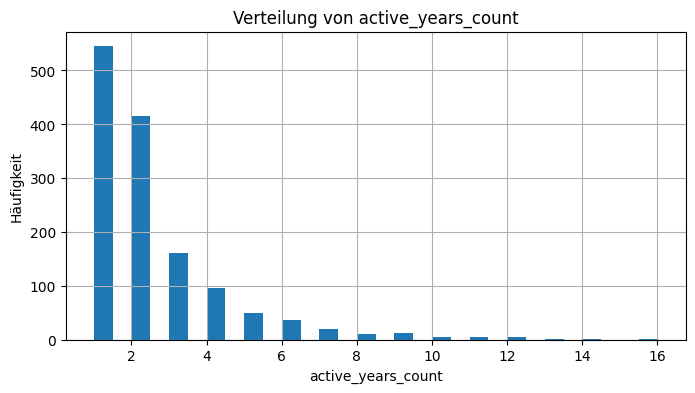

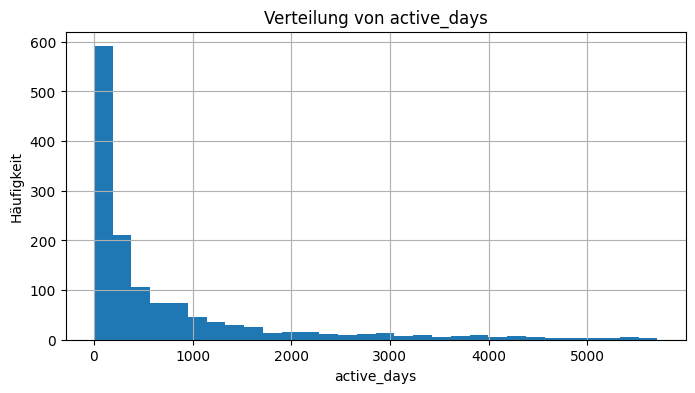

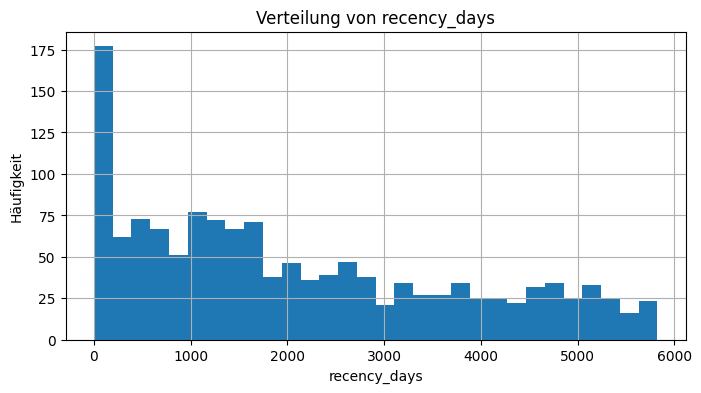

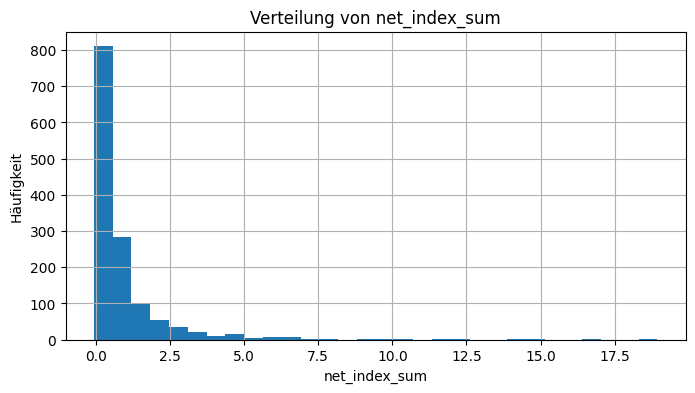

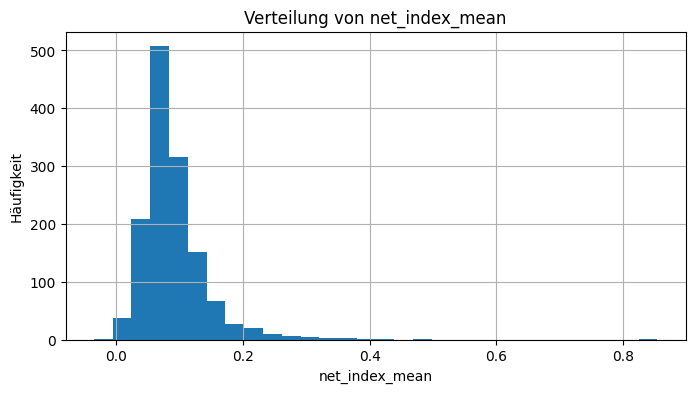

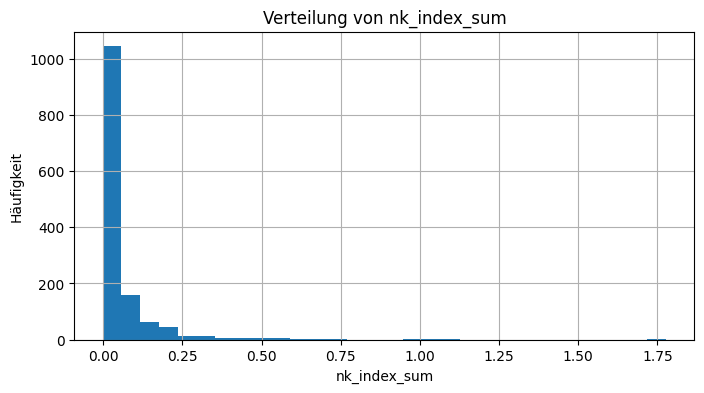

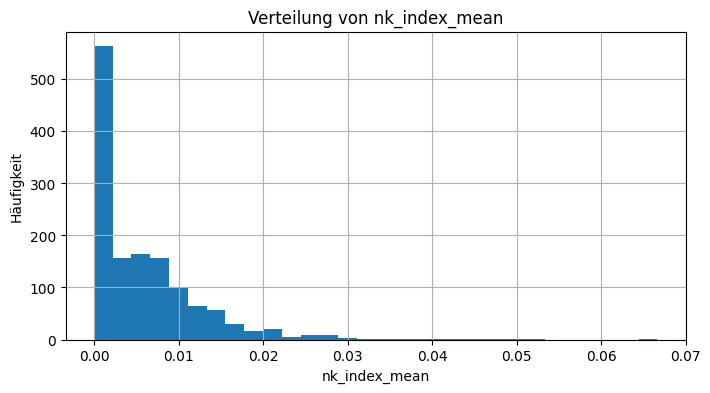

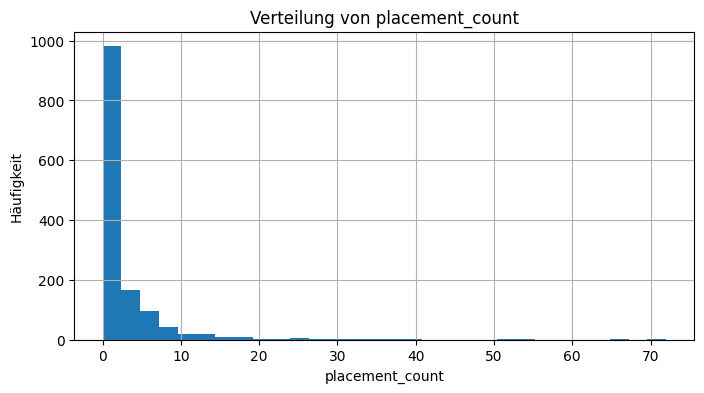

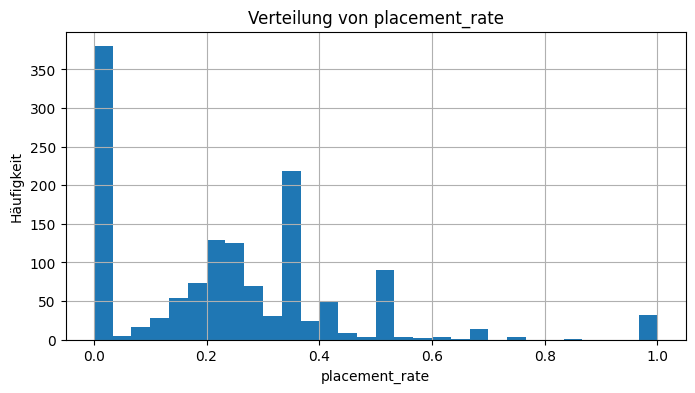

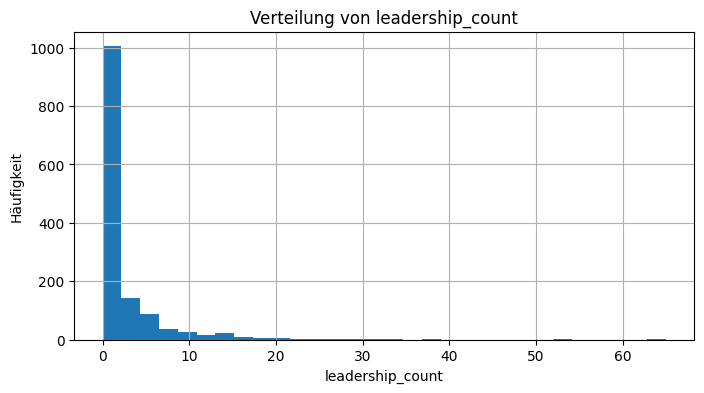

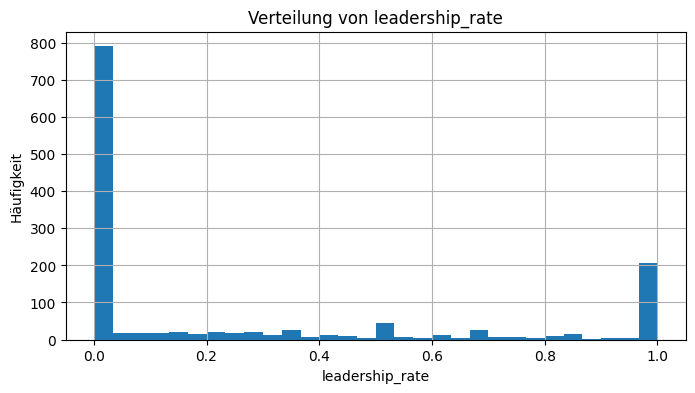

In [769]:
# Verteilungen zentraler numerischer Features

plot_cols = [
    "invoice_count",
    "active_years_count",
    "active_days",
    "recency_days",
    "net_index_sum",
    "net_index_mean",
    "nk_index_sum",
    "nk_index_mean",
    "placement_count",
    "placement_rate",
    "leadership_count",
    "leadership_rate"
]

plot_cols = [col for col in plot_cols if col in eda_df.columns]

for col in plot_cols:
    plt.figure(figsize=(8, 4))
    eda_df[col].dropna().hist(bins=30)
    plt.title(f"Verteilung von {col}")
    plt.xlabel(col)
    plt.ylabel("Häufigkeit")
    plt.show()

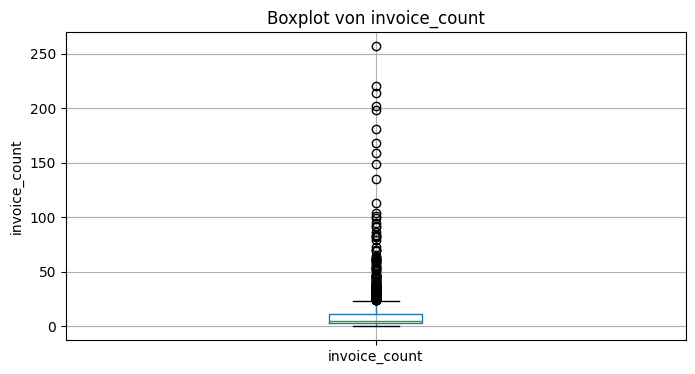

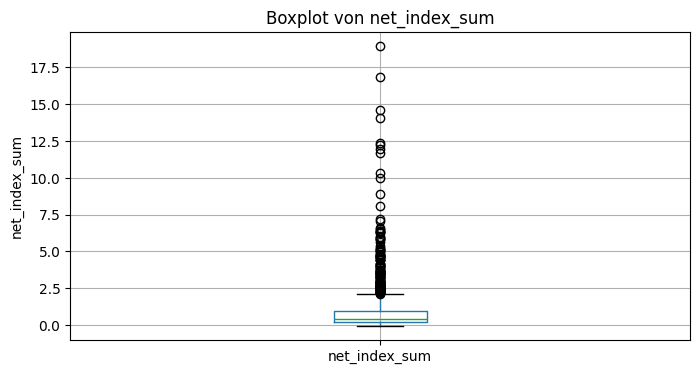

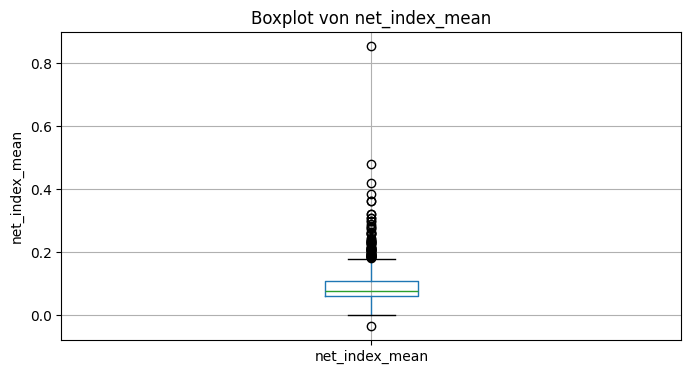

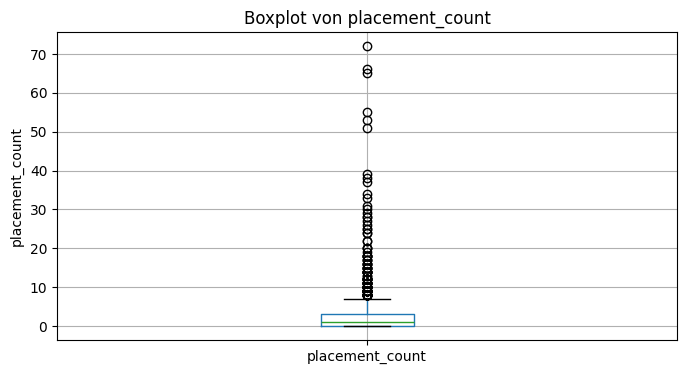

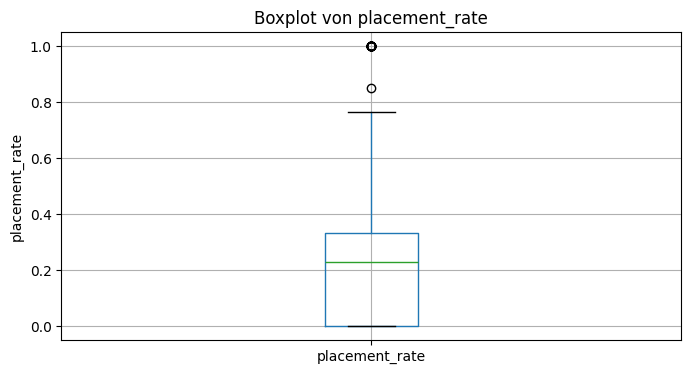

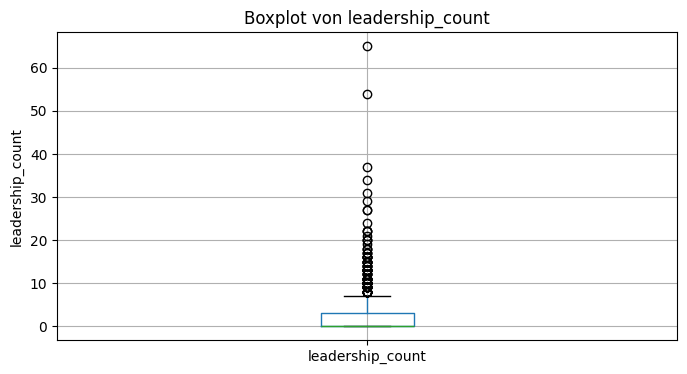

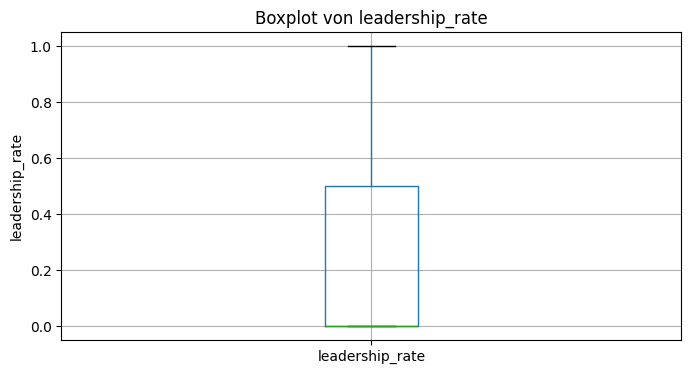

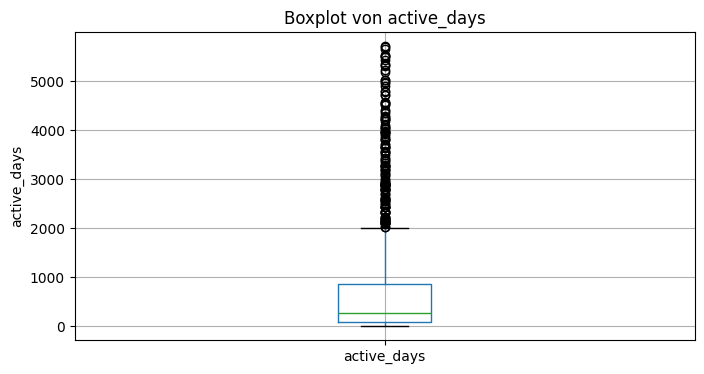

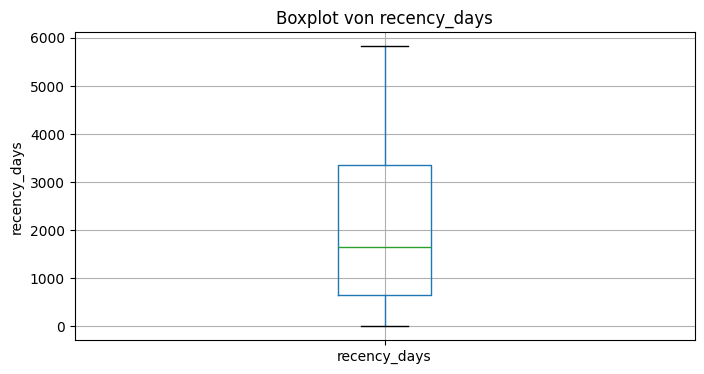

In [770]:
# Boxplots für ausgewählte Kernmerkmale

boxplot_cols = [
    "invoice_count",
    "net_index_sum",
    "net_index_mean",
    "placement_count",
    "placement_rate",
    "leadership_count",
    "leadership_rate",
    "active_days",
    "recency_days"
]

boxplot_cols = [col for col in boxplot_cols if col in eda_df.columns]

for col in boxplot_cols:
    plt.figure(figsize=(8, 4))
    eda_df.boxplot(column=col)
    plt.title(f"Boxplot von {col}")
    plt.ylabel(col)
    plt.show()

In [771]:
# Häufigkeiten zentraler kategorialer Merkmale

categorical_check_cols = [
    "dominant_contract_type",
    "dominant_revenue_subtype",
    "dominant_job_category",
    "dominant_industry"
]

categorical_check_cols = [col for col in categorical_check_cols if col in eda_df.columns]

for col in categorical_check_cols:
    print(f"\nHäufigkeiten für {col}:")
    display(eda_df[col].value_counts(dropna=False).to_frame("count").head(15))


Häufigkeiten für dominant_contract_type:


,count
dominant_contract_type,
Prozent - 3 Raten,747
Pauschal - 3 Raten,323
Prozent mit Anzahlung,120
Pauschal mit Anzahlung,81
Pauschalhonorar,42
Prozentualhonorar,24
N/V,16
Pauschal - 4 Raten,5
Prozent - 4 Raten,4



Häufigkeiten für dominant_revenue_subtype:


,count
dominant_revenue_subtype,
Start,506
Abschluss,303
Präsentation,263
Gutschrift,73
Abbruch,68
Wertberichtigung,53
Erfolgsauftrag,44
Kostenpauschale,19
Nebenkostenpauschale,7



Häufigkeiten für dominant_job_category:


,count
dominant_job_category,
Vertrieb/Presales/Marketing,505
Spezialist (Kerngeschäft),392
C-Level,242
Corporate Services,130
Internal IT,83
Sonstige,8
N/V,4



Häufigkeiten für dominant_industry:


,count
dominant_industry,
Digital & Technology,724
Industrial,262
Financial Services,115
Professional Services,102
Consumer Industries,88
Life Science,47
Sonstige,15
Public Sector,7
N/V,4


In [772]:
# Erste Arbeitsnotizen für die nächsten Schritte

print("- Prüfen, ob invoice_count = 0 auf fehlende Rechnungsnummern oder auf eine fachliche Sonderlogik zurückgeht.")
print("- Negative monetäre Summen fachlich einordnen, zum Beispiel als Gutschrift, Storno oder Korrekturbuchung.")
print("- Stark schiefe Verteilungen und potenzielle Ausreißer für die Baseline im Blick behalten.")
print("- Diversitätsmerkmale wurden nun konsistent aggregiert und können später optional geprüft werden.")
print("- Für die Baseline soll bewusst ein reduziertes Kernfeature-Set verwendet werden, um Redundanzen zu begrenzen.")

- Prüfen, ob invoice_count = 0 auf fehlende Rechnungsnummern oder auf eine fachliche Sonderlogik zurückgeht.
- Negative monetäre Summen fachlich einordnen, zum Beispiel als Gutschrift, Storno oder Korrekturbuchung.
- Stark schiefe Verteilungen und potenzielle Ausreißer für die Baseline im Blick behalten.
- Diversitätsmerkmale wurden nun konsistent aggregiert und können später optional geprüft werden.
- Für die Baseline soll bewusst ein reduziertes Kernfeature-Set verwendet werden, um Redundanzen zu begrenzen.


## Data Cleaning auf Debitor-Ebene

In [773]:
clean_df = debitor_features.copy()

print("Start Data Cleaning")
print(f"Ausgangsbestand Debitoren: {len(clean_df)}")

Start Data Cleaning
Ausgangsbestand Debitoren: 1364


In [774]:
# N/V als fehlende Angabe behandeln

categorical_clean_cols = [
    "dominant_contract_type",
    "dominant_revenue_subtype",
    "dominant_job_category",
    "dominant_industry"
]

categorical_clean_cols = [col for col in categorical_clean_cols if col in clean_df.columns]

for col in categorical_clean_cols:
    nv_count = (clean_df[col] == "N/V").sum()
    print(f"{col}: N/V vor Bereinigung = {nv_count}")
    clean_df[col] = clean_df[col].replace("N/V", np.nan)

print("\nN/V-Bereinigung abgeschlossen.")

dominant_contract_type: N/V vor Bereinigung = 16
dominant_revenue_subtype: N/V vor Bereinigung = 1
dominant_job_category: N/V vor Bereinigung = 4
dominant_industry: N/V vor Bereinigung = 4

N/V-Bereinigung abgeschlossen.


In [775]:
# Debitoren ohne relevante Rechnungsbasis ausschließen

if "invoice_count" in clean_df.columns:
    excluded_invoice_zero = clean_df[clean_df["invoice_count"] == 0].copy()
    clean_df = clean_df[clean_df["invoice_count"] > 0].copy()

    print(f"Ausgeschlossene Debitoren wegen invoice_count == 0: {len(excluded_invoice_zero)}")
    print(f"Debitorenbestand nach invoice_count-Filter: {len(clean_df)}")
else:
    excluded_invoice_zero = pd.DataFrame()
    print("Spalte 'invoice_count' nicht gefunden.")

Ausgeschlossene Debitoren wegen invoice_count == 0: 1
Debitorenbestand nach invoice_count-Filter: 1363


In [776]:
# Debitoren mit negativem Umsatzbezug ausschließen

if "net_index_sum" in clean_df.columns:
    excluded_negative_net = clean_df[clean_df["net_index_sum"] < 0].copy()
    clean_df = clean_df[clean_df["net_index_sum"] >= 0].copy()

    print(f"Ausgeschlossene Debitoren wegen net_index_sum < 0: {len(excluded_negative_net)}")
    print(f"Debitorenbestand nach net_index_sum-Filter: {len(clean_df)}")
else:
    excluded_negative_net = pd.DataFrame()
    print("Spalte 'net_index_sum' nicht gefunden.")

Ausgeschlossene Debitoren wegen net_index_sum < 0: 1
Debitorenbestand nach net_index_sum-Filter: 1362


In [777]:
# Debitoren mit negativem Nebenkostenbezug ausschließen

if "nk_index_sum" in clean_df.columns:
    excluded_negative_nk = clean_df[clean_df["nk_index_sum"] < 0].copy()
    clean_df = clean_df[clean_df["nk_index_sum"] >= 0].copy()

    print(f"Ausgeschlossene Debitoren wegen nk_index_sum < 0: {len(excluded_negative_nk)}")
    print(f"Debitorenbestand nach nk_index_sum-Filter: {len(clean_df)}")
else:
    excluded_negative_nk = pd.DataFrame()
    print("Spalte 'nk_index_sum' nicht gefunden.")

Ausgeschlossene Debitoren wegen nk_index_sum < 0: 1
Debitorenbestand nach nk_index_sum-Filter: 1361


In [778]:
# Überblick über ausgeschlossene Fälle

excluded_cases = []

if len(excluded_invoice_zero) > 0:
    temp = excluded_invoice_zero.copy()
    temp["exclusion_reason"] = "invoice_count == 0"
    excluded_cases.append(temp)

if len(excluded_negative_net) > 0:
    temp = excluded_negative_net.copy()
    temp["exclusion_reason"] = "net_index_sum < 0"
    excluded_cases.append(temp)

if len(excluded_negative_nk) > 0:
    temp = excluded_negative_nk.copy()
    temp["exclusion_reason"] = "nk_index_sum < 0"
    excluded_cases.append(temp)

if excluded_cases:
    excluded_df = pd.concat(excluded_cases, ignore_index=True)
    print(f"Gesamtzahl ausgeschlossener Fälle: {len(excluded_df)}")
    display(excluded_df.head(20))
else:
    excluded_df = pd.DataFrame()
    print("Keine Fälle ausgeschlossen.")

Gesamtzahl ausgeschlossener Fälle: 3


,Debitor,invoice_count,first_invoice_date,last_invoice_date,active_years_count,net_index_sum,net_index_mean,nk_index_sum,nk_index_mean,placement_count,...,dominant_revenue_subtype,dominant_job_category,dominant_industry,contract_type_nunique,revenue_subtype_nunique,job_category_nunique,industry_nunique,active_days,recency_days,exclusion_reason
0,Debitor 128,0,2012-03-06,2012-03-06,1,0.000000,0.000000,0.000000,0.000000,1,...,Replacement,Corporate Services,Professional Services,1,1,1,1,0,5048,invoice_count == 0
1,Debitor 368,2,2010-06-11,2010-06-11,1,-0.071368,-0.035684,0.000000,0.000000,0,...,Abbruch,C-Level,Industrial,1,1,2,1,0,5682,net_index_sum < 0
2,Debitor 1231,46,2013-12-30,2022-10-19,10,1.675676,0.036428,-0.002082,-0.000045,10,...,Start,C-Level,Professional Services,5,10,4,3,3215,1169,nk_index_sum < 0


In [779]:
# Bereinigte Matrix als neue Arbeitsbasis festhalten

debitor_features_clean = clean_df.copy()

print("Bereinigte Debitor-Matrix erstellt.")
print(f"Anzahl Debitoren nach Cleaning: {len(debitor_features_clean)}")
print(f"Anzahl Features nach Cleaning: {debitor_features_clean.shape[1]}")

Bereinigte Debitor-Matrix erstellt.
Anzahl Debitoren nach Cleaning: 1361
Anzahl Features nach Cleaning: 23


In [780]:
# Kurzprüfung nach dem Cleaning

print("Prüfung nach dem Cleaning:")

if "invoice_count" in debitor_features_clean.columns:
    print("invoice_count == 0:", (debitor_features_clean["invoice_count"] == 0).sum())

if "net_index_sum" in debitor_features_clean.columns:
    print("net_index_sum < 0:", (debitor_features_clean["net_index_sum"] < 0).sum())

if "nk_index_sum" in debitor_features_clean.columns:
    print("nk_index_sum < 0:", (debitor_features_clean["nk_index_sum"] < 0).sum())

for col in categorical_clean_cols:
    if col in debitor_features_clean.columns:
        print(f"N/V in {col}:", (debitor_features_clean[col] == "N/V").sum())

Prüfung nach dem Cleaning:
invoice_count == 0: 0
net_index_sum < 0: 0
nk_index_sum < 0: 0
N/V in dominant_contract_type: 0
N/V in dominant_revenue_subtype: 0
N/V in dominant_job_category: 0
N/V in dominant_industry: 0


In [781]:
# Fehlwerte nach der kategorialen Bereinigung erneut prüfen

missing_after_cleaning = pd.DataFrame({
    "missing_count": debitor_features_clean.isna().sum(),
    "missing_pct": (debitor_features_clean.isna().sum() / len(debitor_features_clean) * 100).round(2)
}).sort_values("missing_count", ascending=False)

missing_after_cleaning[missing_after_cleaning["missing_count"] > 0]

,missing_count,missing_pct
dominant_contract_type,15,1.10
dominant_job_category,4,0.29
dominant_industry,4,0.29
dominant_revenue_subtype,1,0.07


In [782]:
# Kurze methodische Notiz zum Cleaning

print("- Debitoren ohne relevante Rechnungsbasis wurden ausgeschlossen.")
print("- Debitoren mit negativem Umsatz- oder Nebenkostenbezug wurden ausgeschlossen.")
print("- N/V wurde in dominanten kategorialen Feldern als fehlende Angabe behandelt.")
print("- Echte numerische Nullwerte wurden beibehalten.")
print("- Die bereinigte Matrix bildet die Grundlage für das nächste Feature Engineering.")

- Debitoren ohne relevante Rechnungsbasis wurden ausgeschlossen.
- Debitoren mit negativem Umsatz- oder Nebenkostenbezug wurden ausgeschlossen.
- N/V wurde in dominanten kategorialen Feldern als fehlende Angabe behandelt.
- Echte numerische Nullwerte wurden beibehalten.
- Die bereinigte Matrix bildet die Grundlage für das nächste Feature Engineering.


In [783]:
# Feature Engineering auf Debitor-Ebene vorbereiten

debitor_features_fe = debitor_features_clean.copy()

print("Ausgangsbasis für Feature Engineering:")
print(f"Debitoren: {debitor_features_fe.shape[0]}")
print(f"Features: {debitor_features_fe.shape[1]}")

Ausgangsbasis für Feature Engineering:
Debitoren: 1361
Features: 23


In [784]:
# Neue Aktivitäts- und Intensitätsmerkmale ableiten

if "invoice_count" in debitor_features_fe.columns and "active_years_count" in debitor_features_fe.columns:
    debitor_features_fe["invoices_per_active_year"] = (
        debitor_features_fe["invoice_count"] / debitor_features_fe["active_years_count"].replace(0, np.nan)
    )

if "net_index_sum" in debitor_features_fe.columns and "active_years_count" in debitor_features_fe.columns:
    debitor_features_fe["net_per_active_year"] = (
        debitor_features_fe["net_index_sum"] / debitor_features_fe["active_years_count"].replace(0, np.nan)
    )

if "placement_count" in debitor_features_fe.columns and "active_years_count" in debitor_features_fe.columns:
    debitor_features_fe["placements_per_active_year"] = (
        debitor_features_fe["placement_count"] / debitor_features_fe["active_years_count"].replace(0, np.nan)
    )

if "leadership_count" in debitor_features_fe.columns and "active_years_count" in debitor_features_fe.columns:
    debitor_features_fe["leadership_per_active_year"] = (
        debitor_features_fe["leadership_count"] / debitor_features_fe["active_years_count"].replace(0, np.nan)
    )

if "net_index_sum" in debitor_features_fe.columns and "invoice_count" in debitor_features_fe.columns:
    debitor_features_fe["net_per_invoice"] = (
        debitor_features_fe["net_index_sum"] / debitor_features_fe["invoice_count"].replace(0, np.nan)
    )

print("Neue Aktivitäts- und Intensitätsmerkmale wurden ergänzt.")
print("Hinweis: Nicht alle neu abgeleiteten Merkmale werden später in die Baseline übernommen.")

Neue Aktivitäts- und Intensitätsmerkmale wurden ergänzt.
Hinweis: Nicht alle neu abgeleiteten Merkmale werden später in die Baseline übernommen.


In [785]:
# Vorhandene Diversitätsmerkmale prüfen

diversity_cols = [
    "contract_type_nunique",
    "revenue_subtype_nunique",
    "job_category_nunique",
    "industry_nunique"
]

available_diversity_cols = [col for col in diversity_cols if col in debitor_features_fe.columns]

print("Verfügbare Diversitätsmerkmale:")
print(available_diversity_cols)

debitor_features_fe[available_diversity_cols].describe().round(3)

Verfügbare Diversitätsmerkmale:
['contract_type_nunique', 'revenue_subtype_nunique', 'job_category_nunique', 'industry_nunique']


,contract_type_nunique,revenue_subtype_nunique,job_category_nunique,industry_nunique
count,1361.000,1361.000,1361.000,1361.000
mean,1.599,3.432,1.677,1.172
std,0.994,1.806,0.980,0.465
min,1.000,1.000,1.000,1.000
25%,1.000,2.000,1.000,1.000
50%,1.000,3.000,1.000,1.000
75%,2.000,4.000,2.000,1.000
max,7.000,12.000,7.000,5.000


In [786]:
# Neue Feature-Spalten sichtbar machen

new_feature_cols = [
    "invoices_per_active_year",
    "net_per_active_year",
    "placements_per_active_year",
    "leadership_per_active_year",
    "net_per_invoice"
]

new_feature_cols = [col for col in new_feature_cols if col in debitor_features_fe.columns]

print("Neu abgeleitete Features:")
print(new_feature_cols)

Neu abgeleitete Features:
['invoices_per_active_year', 'net_per_active_year', 'placements_per_active_year', 'leadership_per_active_year', 'net_per_invoice']


In [787]:
# Deskriptive Statistik der neuen Features

if new_feature_cols:
    debitor_features_fe[new_feature_cols].describe().T
else:
    print("Keine neuen Features vorhanden.")

In [788]:
# Fehlwerte in den neuen Features prüfen

if new_feature_cols:
    missing_new_features = pd.DataFrame({
        "missing_count": debitor_features_fe[new_feature_cols].isna().sum(),
        "missing_pct": (debitor_features_fe[new_feature_cols].isna().sum() / len(debitor_features_fe) * 100).round(2)
    }).sort_values("missing_count", ascending=False)

    missing_new_features[missing_new_features["missing_count"] > 0]
else:
    print("Keine neuen Features vorhanden.")

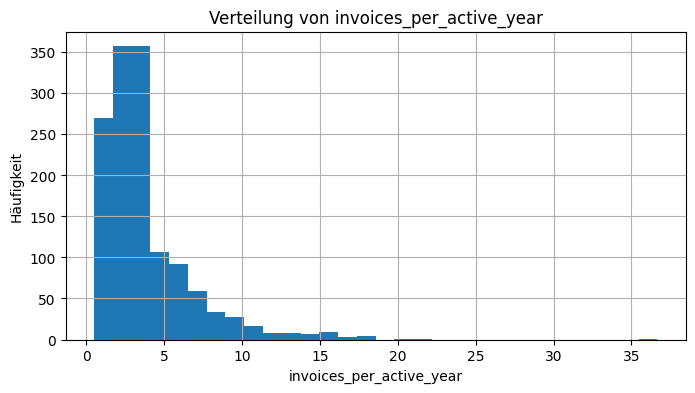

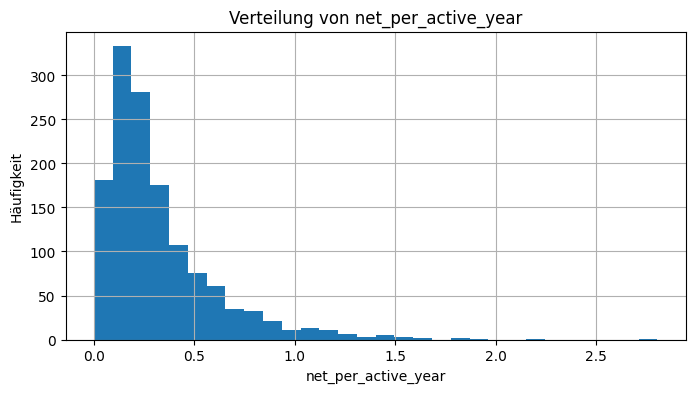

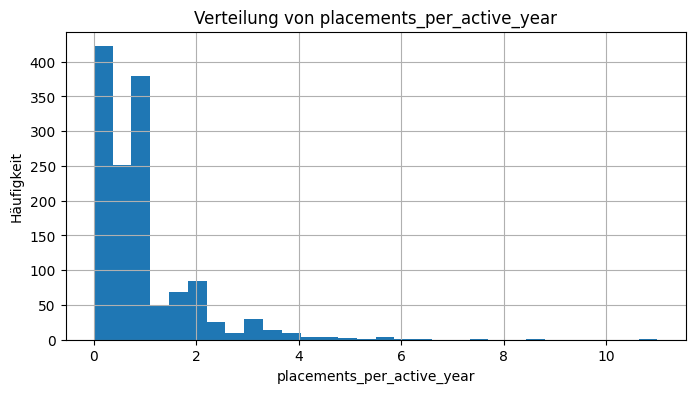

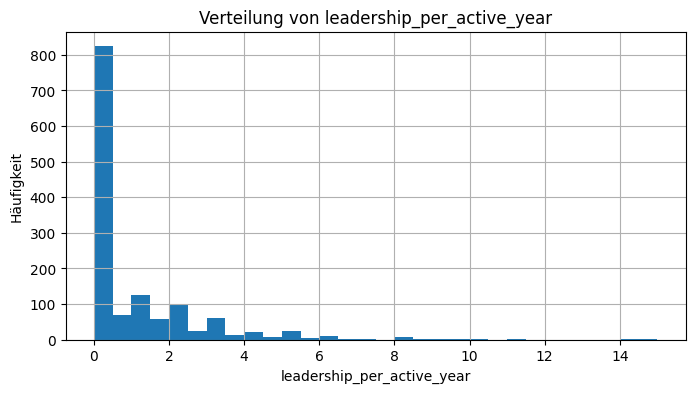

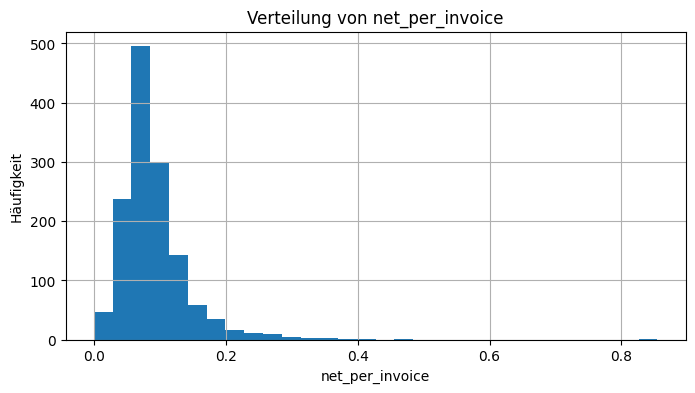

In [789]:
# Verteilungen der neuen Features prüfen

for col in new_feature_cols:
    plt.figure(figsize=(8, 4))
    debitor_features_fe[col].dropna().hist(bins=30)
    plt.title(f"Verteilung von {col}")
    plt.xlabel(col)
    plt.ylabel("Häufigkeit")
    plt.show()

In [790]:
# Feature-Engineering-Stand als neue Arbeitsbasis festhalten

debitor_features_final = debitor_features_fe.copy()

print("Feature Engineering abgeschlossen.")
print(f"Debitoren: {debitor_features_final.shape[0]}")
print(f"Features: {debitor_features_final.shape[1]}")

Feature Engineering abgeschlossen.
Debitoren: 1361
Features: 28


## Überarbeitete Baseline-Logik

Für die erste Cluster-Baseline wird bewusst **kein maximal breites Feature-Set** verwendet. Stattdessen wird eine schlankere Kernmatrix genutzt, um Redundanzen zwischen Aktivitäts-, Volumen- und Ratenmerkmalen zu reduzieren.

Leitidee der Baseline:
- Aktivität und Kundenbindung über wenige, klar interpretierbare Kennzahlen abbilden
- monetäre Größe und monetäre Intensität trennen
- Placement und Führungsanteil nicht mehrfach über Count, Rate und Zeitintensität gleichzeitig abbilden
- Diversitätsmerkmale zunächst dokumentieren, aber nicht automatisch in die Baseline zwingen

Die Baseline ist damit als **bewusst konservative Referenzlösung** zu verstehen. Erweiterte Features können später in Robustheits- und Sensitivitätsanalysen geprüft werden.

In [791]:
# Arbeitsbasis für die Baseline-Modellierung vorbereiten

baseline_df = debitor_features_final.copy()

print("Ausgangsbasis für die Baseline-Modellierung:")
print(f"Debitoren: {baseline_df.shape[0]}")
print(f"Features: {baseline_df.shape[1]}")

Ausgangsbasis für die Baseline-Modellierung:
Debitoren: 1361
Features: 28


In [792]:
# Numerische Kernfeatures für die Baseline festlegen

baseline_feature_candidates = [
    "invoice_count",
    "active_years_count",
    "recency_days",
    "net_index_sum",
    "net_per_invoice",
    "placement_count",
    "placement_rate",
    "leadership_rate"
]

optional_feature_candidates = [
    "invoices_per_active_year",
    "net_per_active_year",
    "nk_index_sum",
    "contract_type_nunique",
    "revenue_subtype_nunique",
    "job_category_nunique",
    "industry_nunique"
]

excluded_redundant_candidates = [
    "active_days",
    "net_index_mean",
    "nk_index_mean",
    "leadership_count",
    "placements_per_active_year",
    "leadership_per_active_year"
]

baseline_feature_cols = [col for col in baseline_feature_candidates if col in baseline_df.columns]
available_optional_feature_cols = [col for col in optional_feature_candidates if col in baseline_df.columns]
available_excluded_feature_cols = [col for col in excluded_redundant_candidates if col in baseline_df.columns]

print("Verwendete Baseline-Features:")
print(baseline_feature_cols)
print()
print("Optional dokumentierte, aber nicht standardmäßig verwendete Features:")
print(available_optional_feature_cols)
print()
print("Bewusst vorerst ausgeschlossene Redundanzkandidaten:")
print(available_excluded_feature_cols)

Verwendete Baseline-Features:
['invoice_count', 'active_years_count', 'recency_days', 'net_index_sum', 'net_per_invoice', 'placement_count', 'placement_rate', 'leadership_rate']

Optional dokumentierte, aber nicht standardmäßig verwendete Features:
['invoices_per_active_year', 'net_per_active_year', 'nk_index_sum', 'contract_type_nunique', 'revenue_subtype_nunique', 'job_category_nunique', 'industry_nunique']

Bewusst vorerst ausgeschlossene Redundanzkandidaten:
['active_days', 'net_index_mean', 'nk_index_mean', 'leadership_count', 'placements_per_active_year', 'leadership_per_active_year']


In [793]:
# Erste Baseline-Feature-Matrix erzeugen

X_baseline_raw = baseline_df[baseline_feature_cols].copy()

print("Form der Baseline-Feature-Matrix:")
print(X_baseline_raw.shape)

X_baseline_raw.head()

Form der Baseline-Feature-Matrix:
(1361, 8)


,invoice_count,active_years_count,recency_days,net_index_sum,net_per_invoice,placement_count,placement_rate,leadership_rate
0,101,16,34,5.974359,0.059152,30,0.29703,0.000000
1,1,1,2591,0.042735,0.042735,1,1.00000,0.000000
2,36,7,96,2.910427,0.080845,9,0.25000,0.333333
3,2,2,4668,0.153846,0.076923,1,0.50000,0.000000
4,4,1,5160,0.307692,0.076923,0,0.00000,0.000000


In [794]:
# Korrelationen innerhalb der Baseline grob prüfen

baseline_corr = X_baseline_raw.corr(numeric_only=True).round(3)
baseline_corr

,invoice_count,active_years_count,recency_days,net_index_sum,net_per_invoice,placement_count,placement_rate,leadership_rate
invoice_count,1.000,0.755,-0.190,0.957,-0.074,0.931,0.062,-0.086
active_years_count,0.755,1.000,-0.242,0.751,-0.062,0.727,0.111,-0.111
recency_days,-0.190,-0.242,1.000,-0.240,-0.228,-0.151,0.069,-0.501
net_index_sum,0.957,0.751,-0.240,1.000,0.080,0.936,0.127,-0.033
net_per_invoice,-0.074,-0.062,-0.228,0.080,1.000,-0.007,0.432,0.290
placement_count,0.931,0.727,-0.151,0.936,-0.007,1.000,0.213,-0.114
placement_rate,0.062,0.111,0.069,0.127,0.432,0.213,1.000,-0.098
leadership_rate,-0.086,-0.111,-0.501,-0.033,0.290,-0.114,-0.098,1.000


In [795]:
# Fehlwerte in der Baseline-Feature-Matrix prüfen

missing_baseline = pd.DataFrame({
    "missing_count": X_baseline_raw.isna().sum(),
    "missing_pct": (X_baseline_raw.isna().sum() / len(X_baseline_raw) * 100).round(2)
}).sort_values("missing_count", ascending=False)

missing_baseline[missing_baseline["missing_count"] > 0]

,missing_count,missing_pct


In [796]:
# Fehlende numerische Werte für die Baseline pragmatisch behandeln

X_baseline_prepared = X_baseline_raw.copy()

for col in X_baseline_prepared.columns:
    if X_baseline_prepared[col].isna().sum() > 0:
        median_value = X_baseline_prepared[col].median()
        X_baseline_prepared[col] = X_baseline_prepared[col].fillna(median_value)

print("Fehlende Werte wurden für die Baseline mit dem Median gefüllt.")

Fehlende Werte wurden für die Baseline mit dem Median gefüllt.


In [797]:
# Baseline-Matrix nach der Imputation erneut prüfen

missing_baseline_after = pd.DataFrame({
    "missing_count": X_baseline_prepared.isna().sum(),
    "missing_pct": (X_baseline_prepared.isna().sum() / len(X_baseline_prepared) * 100).round(2)
}).sort_values("missing_count", ascending=False)

missing_baseline_after[missing_baseline_after["missing_count"] > 0]

,missing_count,missing_pct


In [798]:
# Baseline-Matrix standardisieren

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_baseline_scaled = pd.DataFrame(
    scaler.fit_transform(X_baseline_prepared),
    columns=X_baseline_prepared.columns,
    index=X_baseline_prepared.index
)

print("Standardisierte Baseline-Matrix erstellt.")
print(X_baseline_scaled.shape)

X_baseline_scaled.head()

Standardisierte Baseline-Matrix erstellt.
(1361, 8)


,invoice_count,active_years_count,recency_days,net_index_sum,net_per_invoice,placement_count,placement_rate,leadership_rate
0,4.342639,7.015599,-1.230390,3.235321,-0.576122,4.615278,0.321770,-0.686660
1,-0.489616,-0.714510,0.301183,-0.561413,-0.883097,-0.314371,3.748040,-0.686660
2,1.201673,2.377534,-1.193253,1.274149,-0.170492,1.045532,0.092548,0.194965
3,-0.441294,-0.199169,1.545249,-0.490293,-0.243830,-0.314371,1.311045,-0.686660
4,-0.344649,-0.714510,1.839943,-0.391818,-0.243830,-0.484359,-1.125950,-0.686660


In [799]:
# Standardisierung grob prüfen

scaling_check = pd.DataFrame({
    "mean_after_scaling": X_baseline_scaled.mean().round(4),
    "std_after_scaling": X_baseline_scaled.std().round(4)
})

scaling_check.head(10)

,mean_after_scaling,std_after_scaling
invoice_count,-0.0,1.0004
active_years_count,0.0,1.0004
recency_days,-0.0,1.0004
net_index_sum,0.0,1.0004
net_per_invoice,-0.0,1.0004
placement_count,-0.0,1.0004
placement_rate,0.0,1.0004
leadership_rate,-0.0,1.0004


In [800]:
# Eingesetzte Baseline-Features dokumentieren

baseline_feature_overview = pd.DataFrame({
    "feature": baseline_feature_cols
})

baseline_feature_overview

,feature
0,invoice_count
1,active_years_count
2,recency_days
3,net_index_sum
4,net_per_invoice
5,placement_count
6,placement_rate
7,leadership_rate


In [801]:
# Methodische Notiz zur Baseline

print("Methodische Notiz zur Baseline:")
print("- Für die erste Baseline wurden bewusst nur wenige numerische Kernfeatures verwendet.")
print("- Ziel ist eine robuste Referenzlösung mit geringerer Redundanz zwischen Aktivitäts-, Volumen- und Ratenmerkmalen.")
print("- Dominante kategoriale Felder und Diversitätsmerkmale bleiben zunächst dokumentiert, werden aber nicht automatisch in die Baseline aufgenommen.")
print("- Fehlende Werte in numerischen Baseline-Features wurden pragmatisch mit dem Median behandelt.")
print("- Die standardisierte Baseline-Matrix bildet die Grundlage für eine erste metrisch nachvollziehbare Clusteranalyse.")

Methodische Notiz zur Baseline:
- Für die erste Baseline wurden bewusst nur wenige numerische Kernfeatures verwendet.
- Ziel ist eine robuste Referenzlösung mit geringerer Redundanz zwischen Aktivitäts-, Volumen- und Ratenmerkmalen.
- Dominante kategoriale Felder und Diversitätsmerkmale bleiben zunächst dokumentiert, werden aber nicht automatisch in die Baseline aufgenommen.
- Fehlende Werte in numerischen Baseline-Features wurden pragmatisch mit dem Median behandelt.
- Die standardisierte Baseline-Matrix bildet die Grundlage für eine erste metrisch nachvollziehbare Clusteranalyse.


In [802]:
# Arbeitsbasis für das Clustering vorbereiten

clustering_df = debitor_features_final.copy()

print("Ausgangsbasis für das Clustering:")
print(f"Debitoren: {clustering_df.shape[0]}")
print(f"Features: {clustering_df.shape[1]}")
print(f"Baseline-Matrix: {X_baseline_scaled.shape}")

Ausgangsbasis für das Clustering:
Debitoren: 1361
Features: 28
Baseline-Matrix: (1361, 8)


In [803]:
# K-Means für erste Clusterläufe vorbereiten

from sklearn.cluster import KMeans

In [804]:
# Erste K-Means-Läufe für verschiedene Clusterzahlen durchführen

k_values = range(2, 9)

kmeans_runs = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_baseline_scaled)
    
    kmeans_runs.append({
        "k": k,
        "inertia": kmeans.inertia_
    })

kmeans_runs_df = pd.DataFrame(kmeans_runs)
kmeans_runs_df

,k,inertia
0,2,7954.806527
1,3,6307.563458
2,4,5176.927702
3,5,4429.841005
4,6,3890.991979
5,7,3471.945570
6,8,3112.743268


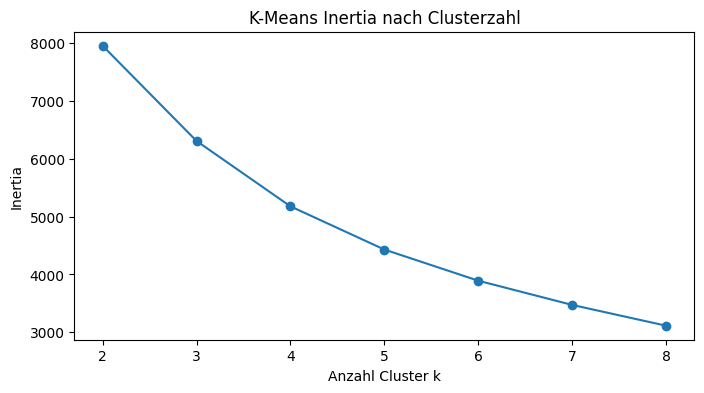

In [805]:
# Inertia für verschiedene Clusterzahlen visualisieren

plt.figure(figsize=(8, 4))
plt.plot(kmeans_runs_df["k"], kmeans_runs_df["inertia"], marker="o")
plt.title("K-Means Inertia nach Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.show()

In [806]:
# Referenz-Clusterzahl für die erste Hauptauswertung festlegen

k_selected = 2
k_exploratory = 4

print(f"Metrisch priorisierte Referenzlösung: k = {k_selected}")
print(f"Explorative Vergleichslösung für spätere fachliche Prüfung: k = {k_exploratory}")

Metrisch priorisierte Referenzlösung: k = 2
Explorative Vergleichslösung für spätere fachliche Prüfung: k = 4


In [807]:
# K-Means mit der gewählten Clusterzahl ausführen

kmeans_final = KMeans(n_clusters=k_selected, random_state=42, n_init=10)
cluster_labels_final = kmeans_final.fit_predict(X_baseline_scaled)

print("K-Means-Lauf abgeschlossen.")
print(f"Anzahl Cluster: {k_selected}")

K-Means-Lauf abgeschlossen.
Anzahl Cluster: 2


In [808]:
# Clusterlabels an die Debitorbasis anhängen

clustering_df["cluster_kmeans"] = cluster_labels_final

print("Clusterlabels wurden ergänzt.")
clustering_df[["cluster_kmeans"]].head()

Clusterlabels wurden ergänzt.


,cluster_kmeans
0,1
1,0
2,0
3,0
4,0


In [809]:
# Clustergrößen prüfen

cluster_sizes = clustering_df["cluster_kmeans"].value_counts().sort_index().to_frame("count")
cluster_sizes

,count
cluster_kmeans,
0,1293
1,68


In [810]:
# Erste numerische Clusterprofile berechnen

cluster_profile_means = clustering_df.groupby("cluster_kmeans")[baseline_feature_cols].mean().round(3)
cluster_profile_means

,invoice_count,active_years_count,recency_days,net_index_sum,net_per_invoice,placement_count,placement_rate,leadership_rate
cluster_kmeans,,,,,,,,
0,7.626,2.084,2150.462,0.649,0.090,1.859,0.228,0.265
1,77.809,8.147,903.647,6.067,0.085,21.676,0.292,0.148


In [811]:
# Clusterprofile auf standardisierter Basis berechnen

X_clustered_scaled = X_baseline_scaled.copy()
X_clustered_scaled["cluster_kmeans"] = cluster_labels_final

cluster_profile_scaled = X_clustered_scaled.groupby("cluster_kmeans").mean().round(3)
cluster_profile_scaled

,invoice_count,active_years_count,recency_days,net_index_sum,net_per_invoice,placement_count,placement_rate,leadership_rate
cluster_kmeans,,,,,,,,
0,-0.169,-0.156,0.037,-0.173,0.005,-0.168,-0.016,0.015
1,3.222,2.969,-0.709,3.295,-0.092,3.200,0.299,-0.294


In [812]:
# Clustering-Ergebnis als neue Arbeitsbasis festhalten

clustering_results_df = clustering_df.copy()

print("Clustering-Arbeitsbasis erstellt.")
print(f"Debitoren: {clustering_results_df.shape[0]}")
print(f"Features inkl. Clusterlabel: {clustering_results_df.shape[1]}")

Clustering-Arbeitsbasis erstellt.
Debitoren: 1361
Features inkl. Clusterlabel: 29


In [813]:
# Methodische Notiz zur Verfahrensauswahl

print("Methodische Notiz zur Clusterwahl:")
print("- Als erstes Clusterverfahren wurde K-Means als Baseline gewählt.")
print("- Die Clusterbildung basiert auf der standardisierten numerischen Baseline-Matrix.")
print("- Mehrere Clusterzahlen wurden zunächst explorativ über die Inertia verglichen.")
print("- Für die erste Hauptauswertung wird die metrisch stärkere Referenzlösung priorisiert.")
print("- Eine feinere Segmentierung kann ergänzend als explorative Arbeitslösung geprüft werden.")
print("- Die formale Bewertung der Clusterqualität folgt im nächsten Schritt.")

Methodische Notiz zur Clusterwahl:
- Als erstes Clusterverfahren wurde K-Means als Baseline gewählt.
- Die Clusterbildung basiert auf der standardisierten numerischen Baseline-Matrix.
- Mehrere Clusterzahlen wurden zunächst explorativ über die Inertia verglichen.
- Für die erste Hauptauswertung wird die metrisch stärkere Referenzlösung priorisiert.
- Eine feinere Segmentierung kann ergänzend als explorative Arbeitslösung geprüft werden.
- Die formale Bewertung der Clusterqualität folgt im nächsten Schritt.


In [814]:
# Validierungsmetriken für die Clusterqualität vorbereiten

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [815]:
# Clusterqualität für verschiedene Clusterzahlen berechnen

k_values = range(2, 9)

cluster_validation_results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_baseline_scaled)

    silhouette = silhouette_score(X_baseline_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_baseline_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_baseline_scaled, labels)

    cluster_validation_results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette_score": silhouette,
        "davies_bouldin_score": davies_bouldin,
        "calinski_harabasz_score": calinski_harabasz
    })

cluster_validation_df = pd.DataFrame(cluster_validation_results)
cluster_validation_df

,k,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,2,7954.806527,0.585023,0.852591,501.107088
1,3,6307.563458,0.280536,1.266724,493.078635
2,4,5176.927702,0.310109,1.102519,499.004143
3,5,4429.841005,0.297993,1.134531,494.219972
4,6,3890.991979,0.261398,1.140150,487.327958
5,7,3471.945570,0.259953,1.121021,482.025201
6,8,3112.743268,0.268457,1.078389,482.804370


In [816]:
# Validierungsergebnisse gerundet darstellen

cluster_validation_df_rounded = cluster_validation_df.copy()

metric_cols = [
    "inertia",
    "silhouette_score",
    "davies_bouldin_score",
    "calinski_harabasz_score"
]

cluster_validation_df_rounded[metric_cols] = cluster_validation_df_rounded[metric_cols].round(4)
cluster_validation_df_rounded

,k,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,2,7954.8065,0.5850,0.8526,501.1071
1,3,6307.5635,0.2805,1.2667,493.0786
2,4,5176.9277,0.3101,1.1025,499.0041
3,5,4429.8410,0.2980,1.1345,494.2200
4,6,3890.9920,0.2614,1.1402,487.3280
5,7,3471.9456,0.2600,1.1210,482.0252
6,8,3112.7433,0.2685,1.0784,482.8044


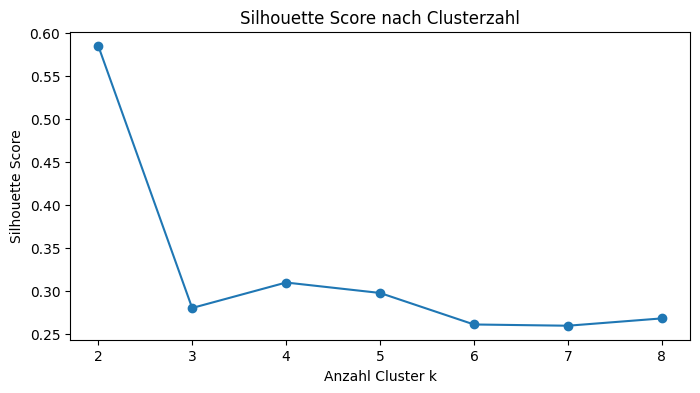

In [817]:
# Silhouette Score visualisieren

plt.figure(figsize=(8, 4))
plt.plot(cluster_validation_df["k"], cluster_validation_df["silhouette_score"], marker="o")
plt.title("Silhouette Score nach Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.show()

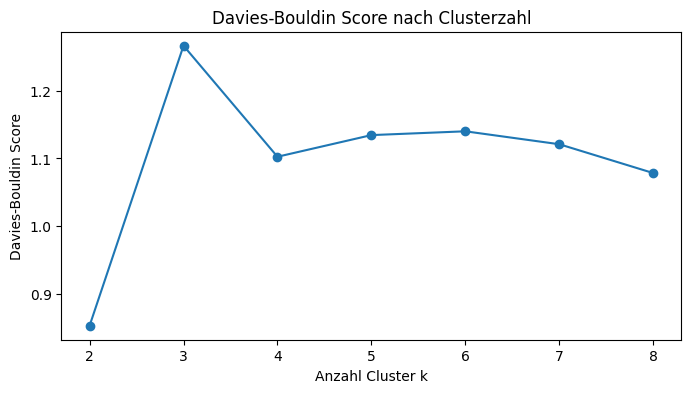

In [818]:
# Davies-Bouldin Score visualisieren

plt.figure(figsize=(8, 4))
plt.plot(cluster_validation_df["k"], cluster_validation_df["davies_bouldin_score"], marker="o")
plt.title("Davies-Bouldin Score nach Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Davies-Bouldin Score")
plt.xticks(list(k_values))
plt.show()

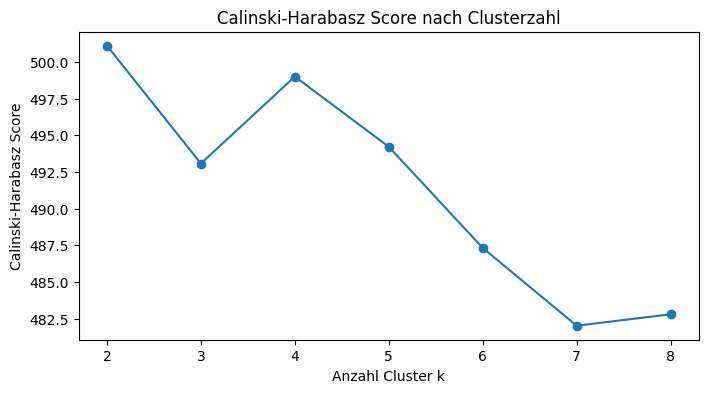

In [819]:
# Calinski-Harabasz Score visualisieren

plt.figure(figsize=(8, 4))
plt.plot(cluster_validation_df["k"], cluster_validation_df["calinski_harabasz_score"], marker="o")
plt.title("Calinski-Harabasz Score nach Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Calinski-Harabasz Score")
plt.xticks(list(k_values))
plt.show()

In [820]:
# Beste Clusterzahl je Metrik identifizieren

best_silhouette_k = cluster_validation_df.loc[cluster_validation_df["silhouette_score"].idxmax(), "k"]
best_davies_bouldin_k = cluster_validation_df.loc[cluster_validation_df["davies_bouldin_score"].idxmin(), "k"]
best_calinski_harabasz_k = cluster_validation_df.loc[cluster_validation_df["calinski_harabasz_score"].idxmax(), "k"]

print(f"Bestes k nach Silhouette Score: {best_silhouette_k}")
print(f"Bestes k nach Davies-Bouldin Score: {best_davies_bouldin_k}")
print(f"Bestes k nach Calinski-Harabasz Score: {best_calinski_harabasz_k}")

Bestes k nach Silhouette Score: 2
Bestes k nach Davies-Bouldin Score: 2
Bestes k nach Calinski-Harabasz Score: 2


In [821]:
# Aktuell gewählte Arbeits-Clusterzahl mit den Metriken abgleichen

selected_k_metrics = cluster_validation_df_rounded[cluster_validation_df_rounded["k"] == k_selected]
selected_k_metrics

,k,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,2,7954.8065,0.585,0.8526,501.1071


In [822]:
# Validierungsergebnisse als Arbeitsbasis festhalten

cluster_validation_results_df = cluster_validation_df.copy()

print("Validierungsergebnisse wurden als Arbeitsbasis gespeichert.")
print(cluster_validation_results_df.shape)

Validierungsergebnisse wurden als Arbeitsbasis gespeichert.
(7, 5)


In [823]:
# Methodische Notiz zur Clusterqualität

print("Methodische Notiz zur Clusterqualität:")
print("- Die Clusterqualität wurde für mehrere Clusterzahlen mit drei Standardmetriken geprüft.")
print("- Berücksichtigt wurden Silhouette Score, Davies-Bouldin Score und Calinski-Harabasz Score.")
print("- Die Metriken dienen als methodische Grundlage für die Wahl einer plausiblen Referenzlösung.")
print("- Eine spätere Entscheidung kann zusätzlich fachliche Interpretierbarkeit und Business-Nutzen berücksichtigen.")
print("- Aktuell wird die Zweierlösung als metrische Referenz priorisiert; eine Viererlösung bleibt explorativ prüfbar.")

Methodische Notiz zur Clusterqualität:
- Die Clusterqualität wurde für mehrere Clusterzahlen mit drei Standardmetriken geprüft.
- Berücksichtigt wurden Silhouette Score, Davies-Bouldin Score und Calinski-Harabasz Score.
- Die Metriken dienen als methodische Grundlage für die Wahl einer plausiblen Referenzlösung.
- Eine spätere Entscheidung kann zusätzlich fachliche Interpretierbarkeit und Business-Nutzen berücksichtigen.
- Aktuell wird die Zweierlösung als metrische Referenz priorisiert; eine Viererlösung bleibt explorativ prüfbar.


## Robustheitsprüfung der Segmentierung
Ziel der Robustheitsprüfung ist es zu prüfen, ob die identifizierte Clusterstruktur stabil bleibt, wenn die Merkmalsbasis in fachlich plausibler Weise variiert wird. Dazu werden mehrere alternative Feature-Sets definiert und mit K-Means über mehrere Clusterzahlen hinweg verglichen. Die Bewertung erfolgt anhand etablierter Clusterqualitätsmetriken, der Clustergrößen sowie der inhaltlichen Interpretierbarkeit der resultierenden Segmentprofile.

In [824]:
# Alternative Feature-Sets für die Robustheitsprüfung definieren

robustness_feature_sets_raw = {
    "A_Referenzbaseline": [
        "invoice_count",
        "active_years_count",
        "recency_days",
        "net_index_sum",
        "net_per_invoice",
        "placement_count",
        "placement_rate",
        "leadership_rate"
    ],
    "B_Groessenreduziert": [
        "active_years_count",
        "recency_days",
        "net_per_invoice",
        "placement_rate",
        "leadership_rate"
    ],
    "C_Relational": [
        "active_years_count",
        "recency_days",
        "net_per_invoice",
        "invoices_per_active_year",
        "net_per_active_year",
        "placement_rate",
        "leadership_rate"
    ],
    "D_Struktur_erweitert": [
        "active_years_count",
        "recency_days",
        "net_per_invoice",
        "placement_rate",
        "leadership_rate",
        "contract_type_nunique",
        "revenue_subtype_nunique",
        "job_category_nunique",
        "industry_nunique"
    ]
}

robustness_feature_sets = {
    variant: [col for col in cols if col in debitor_features_final.columns]
    for variant, cols in robustness_feature_sets_raw.items()
}

print("Verfügbare Feature-Sets für die Robustheitsprüfung:")
for variant, cols in robustness_feature_sets.items():
    print()
    print(f"{variant}:")
    print(cols)

Verfügbare Feature-Sets für die Robustheitsprüfung:

A_Referenzbaseline:
['invoice_count', 'active_years_count', 'recency_days', 'net_index_sum', 'net_per_invoice', 'placement_count', 'placement_rate', 'leadership_rate']

B_Groessenreduziert:
['active_years_count', 'recency_days', 'net_per_invoice', 'placement_rate', 'leadership_rate']

C_Relational:
['active_years_count', 'recency_days', 'net_per_invoice', 'invoices_per_active_year', 'net_per_active_year', 'placement_rate', 'leadership_rate']

D_Struktur_erweitert:
['active_years_count', 'recency_days', 'net_per_invoice', 'placement_rate', 'leadership_rate', 'contract_type_nunique', 'revenue_subtype_nunique', 'job_category_nunique', 'industry_nunique']


In [825]:
# Überblick über enthaltene und fehlende Features je Variante

robustness_feature_set_overview = []

for variant, planned_cols in robustness_feature_sets_raw.items():
    available_cols = robustness_feature_sets[variant]
    missing_cols = [col for col in planned_cols if col not in available_cols]

    robustness_feature_set_overview.append({
        "variante": variant,
        "geplante_features": len(planned_cols),
        "verfuegbare_features": len(available_cols),
        "fehlende_features": ", ".join(missing_cols) if missing_cols else "-"
    })

robustness_feature_set_overview_df = pd.DataFrame(robustness_feature_set_overview)
robustness_feature_set_overview_df

,variante,geplante_features,verfuegbare_features,fehlende_features
0,A_Referenzbaseline,8,8,-
1,B_Groessenreduziert,5,5,-
2,C_Relational,7,7,-
3,D_Struktur_erweitert,9,9,-


In [826]:
# Vorbereitung für die Robustheitsprüfung

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

k_values_robustness = range(2, 7)

robustness_validation_results = []
robustness_prepared_data = {}

base_robustness_df = debitor_features_final.copy()

print("Ausgangsbasis der Robustheitsprüfung:")
print(f"Debitoren: {base_robustness_df.shape[0]}")
print(f"Verfügbare Spalten: {base_robustness_df.shape[1]}")

Ausgangsbasis der Robustheitsprüfung:
Debitoren: 1361
Verfügbare Spalten: 28


In [827]:
# Alle Varianten über mehrere Clusterzahlen hinweg berechnen

for variant_name, feature_cols in robustness_feature_sets.items():
    if len(feature_cols) < 2:
        print(f"Variante {variant_name} wird übersprungen, da weniger als 2 Features verfügbar sind.")
        continue

    X_variant_raw = base_robustness_df[feature_cols].copy()

    imputer = SimpleImputer(strategy="median")
    X_variant_imputed = pd.DataFrame(
        imputer.fit_transform(X_variant_raw),
        columns=feature_cols,
        index=X_variant_raw.index
    )

    scaler = StandardScaler()
    X_variant_scaled = pd.DataFrame(
        scaler.fit_transform(X_variant_imputed),
        columns=feature_cols,
        index=X_variant_imputed.index
    )

    robustness_prepared_data[variant_name] = {
        "feature_cols": feature_cols,
        "X_raw": X_variant_raw,
        "X_imputed": X_variant_imputed,
        "X_scaled": X_variant_scaled
    }

    for k in k_values_robustness:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_variant_scaled)

        robustness_validation_results.append({
            "variante": variant_name,
            "k": k,
            "n_features": len(feature_cols),
            "features": ", ".join(feature_cols),
            "inertia": kmeans.inertia_,
            "silhouette_score": silhouette_score(X_variant_scaled, labels),
            "davies_bouldin_score": davies_bouldin_score(X_variant_scaled, labels),
            "calinski_harabasz_score": calinski_harabasz_score(X_variant_scaled, labels)
        })

print("Robustheitsläufe abgeschlossen.")
print(f"Anzahl Ergebniszeilen: {len(robustness_validation_results)}")

Robustheitsläufe abgeschlossen.
Anzahl Ergebniszeilen: 20


In [828]:
# Validierungsergebnisse der Robustheitsprüfung als DataFrame aufbereiten

robustness_validation_df = pd.DataFrame(robustness_validation_results)

metric_cols = [
    "inertia",
    "silhouette_score",
    "davies_bouldin_score",
    "calinski_harabasz_score"
]

robustness_validation_df_rounded = robustness_validation_df.copy()
robustness_validation_df_rounded[metric_cols] = robustness_validation_df_rounded[metric_cols].round(4)

robustness_validation_df_rounded.sort_values(["variante", "k"]).reset_index(drop=True)

,variante,k,n_features,features,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,A_Referenzbaseline,2,8,"invoice_count, active_years_count, recency_day...",7954.8065,0.5850,0.8526,501.1071
1,A_Referenzbaseline,3,8,"invoice_count, active_years_count, recency_day...",6307.5635,0.2805,1.2667,493.0786
2,A_Referenzbaseline,4,8,"invoice_count, active_years_count, recency_day...",5176.9277,0.3101,1.1025,499.0041
3,A_Referenzbaseline,5,8,"invoice_count, active_years_count, recency_day...",4429.8410,0.2980,1.1345,494.2200
4,A_Referenzbaseline,6,8,"invoice_count, active_years_count, recency_day...",3890.9920,0.2614,1.1402,487.3280
5,B_Groessenreduziert,2,5,"active_years_count, recency_days, net_per_invo...",5158.3603,0.2907,1.4020,433.8168
6,B_Groessenreduziert,3,5,"active_years_count, recency_days, net_per_invo...",4157.5004,0.2999,1.2185,432.3878
7,B_Groessenreduziert,4,5,"active_years_count, recency_days, net_per_invo...",3414.1623,0.3060,1.1956,449.2431
8,B_Groessenreduziert,5,5,"active_years_count, recency_days, net_per_invo...",2882.7018,0.2778,1.1861,461.2545
9,B_Groessenreduziert,6,5,"active_years_count, recency_days, net_per_invo...",2532.7522,0.2852,1.1087,457.1230


In [829]:
# Beste Clusterzahl je Variante identifizieren

best_rows_per_variant = []

for variant_name in robustness_validation_df["variante"].unique():
    variant_df = robustness_validation_df[robustness_validation_df["variante"] == variant_name].copy()

    best_silhouette_row = variant_df.loc[variant_df["silhouette_score"].idxmax()]
    best_db_row = variant_df.loc[variant_df["davies_bouldin_score"].idxmin()]
    best_ch_row = variant_df.loc[variant_df["calinski_harabasz_score"].idxmax()]

    best_rows_per_variant.append({
        "variante": variant_name,
        "bestes_k_silhouette": int(best_silhouette_row["k"]),
        "bestes_k_davies_bouldin": int(best_db_row["k"]),
        "bestes_k_calinski_harabasz": int(best_ch_row["k"]),
        "max_silhouette_score": round(best_silhouette_row["silhouette_score"], 4),
        "min_davies_bouldin_score": round(best_db_row["davies_bouldin_score"], 4),
        "max_calinski_harabasz_score": round(best_ch_row["calinski_harabasz_score"], 4)
    })

robustness_best_k_df = pd.DataFrame(best_rows_per_variant)
robustness_best_k_df

,variante,bestes_k_silhouette,bestes_k_davies_bouldin,bestes_k_calinski_harabasz,max_silhouette_score,min_davies_bouldin_score,max_calinski_harabasz_score
0,A_Referenzbaseline,2,2,2,0.5850,0.8526,501.1071
1,B_Groessenreduziert,4,6,5,0.3060,1.1087,461.2545
2,C_Relational,3,5,3,0.2705,1.3105,370.4531
3,D_Struktur_erweitert,2,2,2,0.3229,1.4251,441.3816


In [830]:
# Referenzvergleich für k = 2 und k = 4 erzeugen

robustness_reference_comparison_df = robustness_validation_df_rounded[
    robustness_validation_df_rounded["k"].isin([2, 4])
].sort_values(["k", "variante"]).reset_index(drop=True)

robustness_reference_comparison_df

,variante,k,n_features,features,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,A_Referenzbaseline,2,8,"invoice_count, active_years_count, recency_day...",7954.8065,0.5850,0.8526,501.1071
1,B_Groessenreduziert,2,5,"active_years_count, recency_days, net_per_invo...",5158.3603,0.2907,1.4020,433.8168
2,C_Relational,2,7,"active_years_count, recency_days, net_per_invo...",7576.5793,0.2252,1.7479,349.8441
3,D_Struktur_erweitert,2,9,"active_years_count, recency_days, net_per_invo...",9246.0351,0.3229,1.4251,441.3816
4,A_Referenzbaseline,4,8,"invoice_count, active_years_count, recency_day...",5176.9277,0.3101,1.1025,499.0041
5,B_Groessenreduziert,4,5,"active_years_count, recency_days, net_per_invo...",3414.1623,0.3060,1.1956,449.2431
6,C_Relational,4,7,"active_years_count, recency_days, net_per_invo...",5429.1613,0.2482,1.3783,341.4135
7,D_Struktur_erweitert,4,9,"active_years_count, recency_days, net_per_invo...",6863.9351,0.2265,1.5641,354.8758


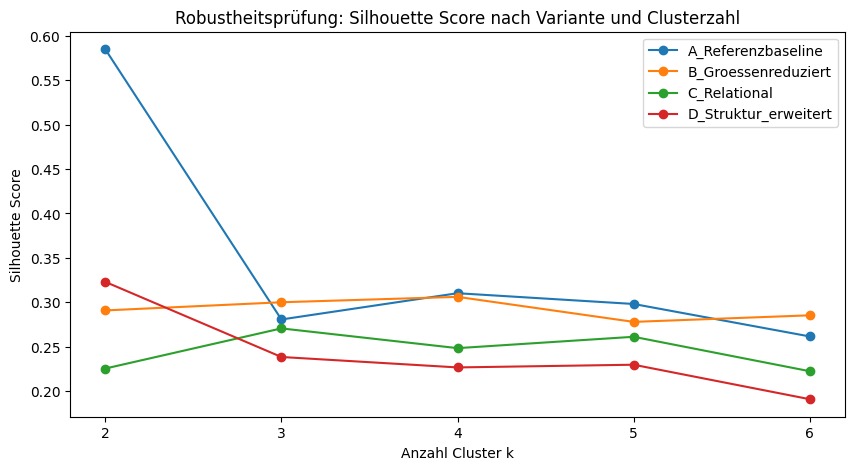

In [831]:
# Silhouette Score je Variante visualisieren

plt.figure(figsize=(10, 5))

for variant_name in robustness_validation_df["variante"].unique():
    plot_df = robustness_validation_df[robustness_validation_df["variante"] == variant_name]
    plt.plot(plot_df["k"], plot_df["silhouette_score"], marker="o", label=variant_name)

plt.title("Robustheitsprüfung: Silhouette Score nach Variante und Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values_robustness))
plt.legend()
plt.show()

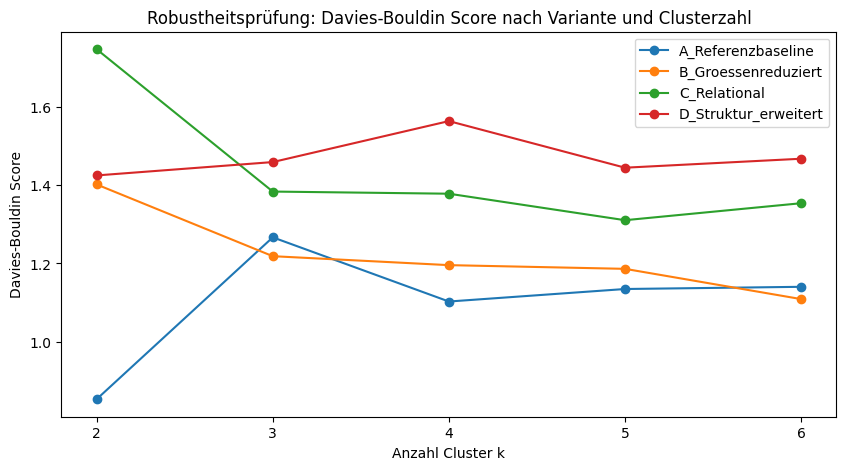

In [832]:
# Davies-Bouldin Score je Variante visualisieren

plt.figure(figsize=(10, 5))

for variant_name in robustness_validation_df["variante"].unique():
    plot_df = robustness_validation_df[robustness_validation_df["variante"] == variant_name]
    plt.plot(plot_df["k"], plot_df["davies_bouldin_score"], marker="o", label=variant_name)

plt.title("Robustheitsprüfung: Davies-Bouldin Score nach Variante und Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Davies-Bouldin Score")
plt.xticks(list(k_values_robustness))
plt.legend()
plt.show()

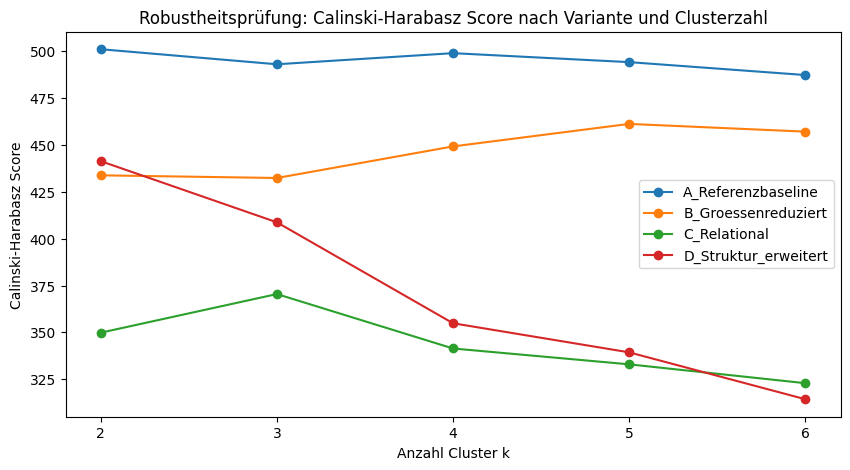

In [833]:
# Calinski-Harabasz Score je Variante visualisieren

plt.figure(figsize=(10, 5))

for variant_name in robustness_validation_df["variante"].unique():
    plot_df = robustness_validation_df[robustness_validation_df["variante"] == variant_name]
    plt.plot(plot_df["k"], plot_df["calinski_harabasz_score"], marker="o", label=variant_name)

plt.title("Robustheitsprüfung: Calinski-Harabasz Score nach Variante und Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Calinski-Harabasz Score")
plt.xticks(list(k_values_robustness))
plt.legend()
plt.show()

In [834]:
# Für jede Variante die metrisch beste k=2- oder k=4-Lösung als Arbeitsbasis auswählen

robustness_selected_models = {}

for variant_name, prepared in robustness_prepared_data.items():
    variant_results = robustness_validation_df[
        (robustness_validation_df["variante"] == variant_name) &
        (robustness_validation_df["k"].isin([2, 4]))
    ].copy()

    if variant_results.empty:
        continue

    selected_row = variant_results.loc[variant_results["silhouette_score"].idxmax()]
    selected_k = int(selected_row["k"])

    X_variant_scaled = prepared["X_scaled"]
    feature_cols = prepared["feature_cols"]

    kmeans = KMeans(n_clusters=selected_k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_variant_scaled)

    result_df = base_robustness_df.copy()
    cluster_col = f"cluster_{variant_name}"
    result_df[cluster_col] = labels

    cluster_sizes_df = (
        result_df[cluster_col]
        .value_counts()
        .sort_index()
        .reset_index()
    )
    cluster_sizes_df.columns = ["cluster", "count"]

    cluster_profile_means_df = (
        result_df.groupby(cluster_col)[feature_cols]
        .mean()
        .round(3)
    )

    robustness_selected_models[variant_name] = {
        "selected_k": selected_k,
        "feature_cols": feature_cols,
        "cluster_col": cluster_col,
        "result_df": result_df,
        "cluster_sizes_df": cluster_sizes_df,
        "cluster_profile_means_df": cluster_profile_means_df
    }

print("Ausgewählte Vergleichsmodelle:")
for variant_name, model in robustness_selected_models.items():
    print(f"{variant_name}: k = {model['selected_k']}")

Ausgewählte Vergleichsmodelle:
A_Referenzbaseline: k = 2
B_Groessenreduziert: k = 4
C_Relational: k = 4
D_Struktur_erweitert: k = 2


In [835]:
# Clustergrößen der ausgewählten Vergleichsmodelle zusammenführen

cluster_size_overview = []

for variant_name, model in robustness_selected_models.items():
    temp_df = model["cluster_sizes_df"].copy()
    temp_df["variante"] = variant_name
    temp_df["k"] = model["selected_k"]
    cluster_size_overview.append(temp_df)

robustness_cluster_sizes_overview_df = pd.concat(cluster_size_overview, ignore_index=True)
robustness_cluster_sizes_overview_df = robustness_cluster_sizes_overview_df[
    ["variante", "k", "cluster", "count"]
]

robustness_cluster_sizes_overview_df

,variante,k,cluster,count
0,A_Referenzbaseline,2,0,1293
1,A_Referenzbaseline,2,1,68
2,B_Groessenreduziert,4,0,197
3,B_Groessenreduziert,4,1,364
4,B_Groessenreduziert,4,2,213
5,B_Groessenreduziert,4,3,587
6,C_Relational,4,0,196
7,C_Relational,4,1,595
8,C_Relational,4,2,358
9,C_Relational,4,3,212


In [836]:
# Clusterprofile je Variante ausgeben

for variant_name, model in robustness_selected_models.items():
    print("=" * 100)
    print(f"Variante: {variant_name}")
    print(f"Verwendete Clusterzahl: {model['selected_k']}")
    print(f"Features: {model['feature_cols']}")
    print()
    print("Clustergrößen:")
    display(model["cluster_sizes_df"])
    print()
    print("Mittlere Clusterprofile auf Originalskala:")
    display(model["cluster_profile_means_df"])
    print()

Variante: A_Referenzbaseline
Verwendete Clusterzahl: 2
Features: ['invoice_count', 'active_years_count', 'recency_days', 'net_index_sum', 'net_per_invoice', 'placement_count', 'placement_rate', 'leadership_rate']

Clustergrößen:


,cluster,count
0,0,1293
1,1,68



Mittlere Clusterprofile auf Originalskala:


,invoice_count,active_years_count,recency_days,net_index_sum,net_per_invoice,placement_count,placement_rate,leadership_rate
cluster_A_Referenzbaseline,,,,,,,,
0,7.626,2.084,2150.462,0.649,0.090,1.859,0.228,0.265
1,77.809,8.147,903.647,6.067,0.085,21.676,0.292,0.148



Variante: B_Groessenreduziert
Verwendete Clusterzahl: 4
Features: ['active_years_count', 'recency_days', 'net_per_invoice', 'placement_rate', 'leadership_rate']

Clustergrößen:


...

,active_years_count,recency_days,net_per_invoice,invoices_per_active_year,net_per_active_year,placement_rate,leadership_rate
cluster_C_Relational,,,,,,,
0,1.883,2785.929,0.134,2.479,0.312,0.547,0.072
1,1.934,2928.156,0.063,2.882,0.177,0.142,0.019
2,1.953,859.704,0.109,3.024,0.313,0.180,0.797
3,4.854,1160.033,0.093,8.652,0.762,0.273,0.200



Variante: D_Struktur_erweitert
Verwendete Clusterzahl: 2
Features: ['active_years_count', 'recency_days', 'net_per_invoice', 'placement_rate', 'leadership_rate', 'contract_type_nunique', 'revenue_subtype_nunique', 'job_category_nunique', 'industry_nunique']

Clustergrößen:


,cluster,count
0,0,1082
1,1,279



Mittlere Clusterprofile auf Originalskala:


,active_years_count,recency_days,net_per_invoice,placement_rate,leadership_rate,contract_type_nunique,revenue_subtype_nunique,job_category_nunique,industry_nunique
cluster_D_Struktur_erweitert,,,,,,,,,
0,1.671,2198.426,0.092,0.218,0.285,1.252,2.802,1.340,1.061
1,5.161,1660.570,0.083,0.281,0.162,2.943,5.875,2.986,1.602


## Inhaltliche Segmentbewertung und Ableitung von Clusterprofilen
Nach der Robustheitsprüfung werden die inhaltlich relevanten Varianten `B_Groessenreduziert` und `C_Relational` vertieft analysiert. Ziel ist es, die Cluster nicht nur anhand der im Modell verwendeten Merkmale, sondern über zusätzliche business-relevante Kennzahlen zu beschreiben und daraus erste fachliche Segmentprofile abzuleiten.

In [837]:
# Relevante Varianten für die inhaltliche Segmentbewertung festlegen

interpretation_variants = ["B_Groessenreduziert", "C_Relational"]

business_profile_features = [
    "invoice_count",
    "active_years_count",
    "recency_days",
    "net_index_sum",
    "net_per_invoice",
    "placement_count",
    "placement_rate",
    "leadership_rate",
    "invoices_per_active_year",
    "net_per_active_year"
]

available_business_profile_features = [
    col for col in business_profile_features if col in debitor_features_final.columns
]

print("Für die inhaltliche Interpretation verwendete Zusatzmerkmale:")
print(available_business_profile_features)

Für die inhaltliche Interpretation verwendete Zusatzmerkmale:
['invoice_count', 'active_years_count', 'recency_days', 'net_index_sum', 'net_per_invoice', 'placement_count', 'placement_rate', 'leadership_rate', 'invoices_per_active_year', 'net_per_active_year']


In [838]:
# Erweiterte Clusterprofile für die inhaltlich relevanten Varianten erzeugen

interpretation_profiles = {}

for variant_name in interpretation_variants:
    if variant_name not in robustness_selected_models:
        print(f"Variante {variant_name} wurde nicht in robustness_selected_models gefunden.")
        continue

    model = robustness_selected_models[variant_name]
    result_df = model["result_df"].copy()
    cluster_col = model["cluster_col"]

    extended_profile_df = (
        result_df.groupby(cluster_col)[available_business_profile_features]
        .mean()
        .round(3)
    )

    cluster_size_df = (
        result_df[cluster_col]
        .value_counts()
        .sort_index()
        .reset_index()
    )
    cluster_size_df.columns = ["cluster", "count"]

    interpretation_profiles[variant_name] = {
        "cluster_col": cluster_col,
        "cluster_sizes": cluster_size_df,
        "extended_profile_df": extended_profile_df
    }

for variant_name, profile_data in interpretation_profiles.items():
    print("=" * 100)
    print(f"Variante: {variant_name}")
    print()
    print("Clustergrößen:")
    display(profile_data["cluster_sizes"])
    print()
    print("Erweiterte Clusterprofile:")
    display(profile_data["extended_profile_df"])
    print()

Variante: B_Groessenreduziert

Clustergrößen:


,cluster,count
0,0,197
1,1,364
2,2,213
3,3,587



Erweiterte Clusterprofile:


,invoice_count,active_years_count,recency_days,net_index_sum,net_per_invoice,placement_count,placement_rate,leadership_rate,invoices_per_active_year,net_per_active_year
cluster_B_Groessenreduziert,,,,,,,,,,
0,5.411,1.751,2851.269,0.677,0.136,2.640,0.554,0.069,2.923,0.376
1,6.484,1.764,828.827,0.695,0.113,1.335,0.181,0.808,3.582,0.389
2,37.911,5.869,1042.535,2.965,0.083,10.146,0.269,0.162,5.940,0.473
3,6.218,1.722,2992.407,0.399,0.063,1.211,0.140,0.019,3.361,0.211



Variante: C_Relational

Clustergrößen:


,cluster,count
0,0,196
1,1,595
2,2,358
3,3,212



Erweiterte Clusterprofile:


,invoice_count,active_years_count,recency_days,net_index_sum,net_per_invoice,placement_count,placement_rate,leadership_rate,invoices_per_active_year,net_per_active_year
cluster_C_Relational,,,,,,,,,,
0,4.745,1.883,2785.929,0.577,0.134,2.255,0.547,0.072,2.479,0.312
1,5.718,1.934,2928.156,0.364,0.063,1.108,0.142,0.019,2.882,0.177
2,5.955,1.953,859.704,0.606,0.109,1.201,0.180,0.797,3.024,0.313
3,40.976,4.854,1160.033,3.327,0.093,11.071,0.273,0.200,8.652,0.762


In [839]:
# Clusterprofile innerhalb jeder Variante relativ zum jeweiligen Variantenmittel vergleichen

interpretation_relative_profiles = {}

for variant_name in interpretation_variants:
    if variant_name not in interpretation_profiles:
        continue

    model = robustness_selected_models[variant_name]
    result_df = model["result_df"].copy()
    cluster_col = model["cluster_col"]

    cluster_means = result_df.groupby(cluster_col)[available_business_profile_features].mean()
    overall_means = result_df[available_business_profile_features].mean()

    relative_profile_df = (cluster_means / overall_means).round(2)

    interpretation_relative_profiles[variant_name] = relative_profile_df

for variant_name, relative_df in interpretation_relative_profiles.items():
    print("=" * 100)
    print(f"Relative Clusterprofile im Vergleich zum Variantenmittel: {variant_name}")
    display(relative_df)
    print()

Relative Clusterprofile im Vergleich zum Variantenmittel: B_Groessenreduziert


,invoice_count,active_years_count,recency_days,net_index_sum,net_per_invoice,placement_count,placement_rate,leadership_rate,invoices_per_active_year,net_per_active_year
cluster_B_Groessenreduziert,,,,,,,,,,
0,0.49,0.73,1.37,0.74,1.51,0.93,2.40,0.27,0.78,1.16
1,0.58,0.74,0.40,0.76,1.26,0.47,0.78,3.11,0.95,1.20
2,3.41,2.46,0.50,3.22,0.92,3.56,1.16,0.62,1.58,1.46
3,0.56,0.72,1.43,0.43,0.70,0.43,0.61,0.07,0.89,0.65



Relative Clusterprofile im Vergleich zum Variantenmittel: C_Relational


,invoice_count,active_years_count,recency_days,net_index_sum,net_per_invoice,placement_count,placement_rate,leadership_rate,invoices_per_active_year,net_per_active_year
cluster_C_Relational,,,,,,,,,,
0,0.43,0.79,1.33,0.63,1.49,0.79,2.37,0.28,0.66,0.97
1,0.51,0.81,1.40,0.40,0.70,0.39,0.62,0.07,0.77,0.55
2,0.53,0.82,0.41,0.66,1.21,0.42,0.78,3.07,0.80,0.97
3,3.68,2.03,0.56,3.62,1.03,3.89,1.18,0.77,2.30,2.35


### Methodische Arbeitslogik zur Segmentbenennung

Die Segmentbenennung erfolgt nicht rein auf Basis der Metriken, sondern anhand einer kombinierten Betrachtung aus Aktualität, Beziehungsdauer, wirtschaftlicher Intensität, Placement-Fokus und Führungsorientierung. Ziel ist eine nachvollziehbare Business-Interpretation, nicht die rein technische Beschreibung von Clusterunterschieden.

In [840]:
# Arbeitsmatrix zur späteren Segmentbenennung vorbereiten

segment_naming_summary = []

for variant_name in interpretation_variants:
    if variant_name not in interpretation_profiles:
        continue

    abs_df = interpretation_profiles[variant_name]["extended_profile_df"]
    rel_df = interpretation_relative_profiles[variant_name]

    for cluster_id in abs_df.index:
        row = {
            "variante": variant_name,
            "cluster": int(cluster_id)
        }

        for col in available_business_profile_features:
            row[f"{col}_mean"] = round(abs_df.loc[cluster_id, col], 3)
            row[f"{col}_rel"] = round(rel_df.loc[cluster_id, col], 2)

        segment_naming_summary.append(row)

segment_naming_summary_df = pd.DataFrame(segment_naming_summary)
segment_naming_summary_df

,variante,cluster,invoice_count_mean,invoice_count_rel,active_years_count_mean,active_years_count_rel,recency_days_mean,recency_days_rel,net_index_sum_mean,net_index_sum_rel,...,placement_count_mean,placement_count_rel,placement_rate_mean,placement_rate_rel,leadership_rate_mean,leadership_rate_rel,invoices_per_active_year_mean,invoices_per_active_year_rel,net_per_active_year_mean,net_per_active_year_rel
0,B_Groessenreduziert,0,5.411,0.49,1.751,0.73,2851.269,1.37,0.677,0.74,...,2.640,0.93,0.554,2.40,0.069,0.27,2.923,0.78,0.376,1.16
1,B_Groessenreduziert,1,6.484,0.58,1.764,0.74,828.827,0.40,0.695,0.76,...,1.335,0.47,0.181,0.78,0.808,3.11,3.582,0.95,0.389,1.20
2,B_Groessenreduziert,2,37.911,3.41,5.869,2.46,1042.535,0.50,2.965,3.22,...,10.146,3.56,0.269,1.16,0.162,0.62,5.940,1.58,0.473,1.46
3,B_Groessenreduziert,3,6.218,0.56,1.722,0.72,2992.407,1.43,0.399,0.43,...,1.211,0.43,0.140,0.61,0.019,0.07,3.361,0.89,0.211,0.65
4,C_Relational,0,4.745,0.43,1.883,0.79,2785.929,1.33,0.577,0.63,...,2.255,0.79,0.547,2.37,0.072,0.28,2.479,0.66,0.312,0.97
5,C_Relational,1,5.718,0.51,1.934,0.81,2928.156,1.40,0.364,0.40,...,1.108,0.39,0.142,0.62,0.019,0.07,2.882,0.77,0.177,0.55
6,C_Relational,2,5.955,0.53,1.953,0.82,859.704,0.41,0.606,0.66,...,1.201,0.42,0.180,0.78,0.797,3.07,3.024,0.80,0.313,0.97
7,C_Relational,3,40.976,3.68,4.854,2.03,1160.033,0.56,3.327,3.62,...,11.071,3.89,0.273,1.18,0.200,0.77,8.652,2.30,0.762,2.35


## Methodische Auswahl der Interpretationslösung

Die Referenzbaseline liefert die stärksten Clusterqualitätsmetriken, ist jedoch stark unbalanciert und bildet primär eine Größen- und Intensitätslogik ab. Für die inhaltliche Segmentinterpretation wird daher die Variante `C_Relational` als fachliche Hauptlösung verwendet. Diese Variante liefert zwar schwächere Metriken, zeigt jedoch balanciertere und inhaltlich besser interpretierbare Beziehungstypen.

## Inhaltliche Interpretation der Segmente

Auf Basis der relationalen Variantenlogik lassen sich vier vorläufige Kundentypen unterscheiden:

### Cluster 0: Selektive Placement-Mandate
Dieses Segment umfasst Debitoren mit vergleichsweise hohem Wert pro Rechnung und hoher Placement-Rate, jedoch geringer Beziehungsdauer und begrenzter Kontinuität. Es handelt sich damit eher um selektive, wertige Einzel- oder Kurzbeziehungen mit klarem Placement-Fokus.

### Cluster 1: Schwache Gelegenheitskunden
Dieses Segment ist durch geringe wirtschaftliche Intensität, niedrige Placement- und Leadership-Anteile sowie hohe Recency geprägt. Die Beziehungen erscheinen eher randständig, wenig fokussiert und aus Akquise-Sicht nur begrenzt attraktiv.

### Cluster 2: Führungsorientierte Suchkunden
Dieses Segment weist besonders hohe Leadership-Anteile und vergleichsweise aktuelle Aktivität auf. Es bildet damit einen Kundentyp ab, der stark auf Führungspositionen ausgerichtet ist und fachlich gut zum Executive-Search-Kontext passt.

### Cluster 3: Langfristige Kernkunden
Dieses Segment vereint hohe Beziehungsdauer, hohe Aktivität und die stärkste wirtschaftliche Intensität. Es beschreibt damit die strategisch relevantesten und historisch tragfähigsten Kundenbeziehungen im Bestand.

## Erste Business-Einordnung

Aus Akquise-Sicht erscheinen insbesondere zwei Segmente besonders relevant: die langfristigen Kernkunden sowie die führungsorientierten Suchkunden. Selektive Placement-Mandate können als ergänzend attraktiver Spezialtyp betrachtet werden, während schwache Gelegenheitskunden eher als niedrig priorisierte Vergleichsgruppe dienen. Diese Einordnung bildet die Grundlage für den nächsten Schritt, in dem die identifizierten Muster in ein konzeptionelles Lookalike-Prinzip für externe Zielunternehmen überführt werden.

## Heuristischer Lookalike-PoC für externe Zielunternehmen

Nach der internen Segmentierung bestehender Debitoren wird im nächsten Schritt ein kleiner heuristischer Proof of Concept für externe Zielunternehmen aufgebaut. Ziel ist nicht die Entwicklung eines validierten externen Scoring-Modells, sondern die nachvollziehbare Demonstration, wie sich interne Segmentmuster in eine einfache Ähnlichkeitslogik für potenzielle Zielkunden übertragen lassen.

Dafür wird eine kleine externe Beispiel-Unternehmensliste mit fünf Proxy-Signalen aufgebaut:

- `leadership_hiring_signal`
- `hiring_continuity_signal`
- `growth_signal`
- `transformation_signal`
- `management_change_signal`

Die Signale werden auf einer einfachen ordinalen Skala von 0 bis 2 abgebildet:

- `0` = kein erkennbares Signal
- `1` = moderates Signal
- `2` = starkes Signal

Anschließend werden zwei segmentbezogene Fit-Heuristiken angewendet:

- `fit_longterm_core_client`
- `fit_leadership_search_client`

Die folgende Demonstration dient ausschließlich der methodischen Veranschaulichung eines möglichen Lookalike-Transfers.

In [841]:
import pandas as pd

external_companies_poc = pd.DataFrame([
    {
        "company_name": "AlphaTech Systems",
        "industry": "Technology",
        "country": "Germany",
        "source_reference": "PoC example",
        "leadership_hiring_signal": 2,
        "hiring_continuity_signal": 2,
        "growth_signal": 2,
        "transformation_signal": 1,
        "management_change_signal": 1,
        "signal_evidence": "Strong executive hiring activity, sustained recruiting, visible growth dynamics."
    },
    {
        "company_name": "NordIndustrial Group",
        "industry": "Industrial Manufacturing",
        "country": "Germany",
        "source_reference": "PoC example",
        "leadership_hiring_signal": 1,
        "hiring_continuity_signal": 2,
        "growth_signal": 1,
        "transformation_signal": 1,
        "management_change_signal": 0,
        "signal_evidence": "Ongoing hiring demand with moderate growth and selective leadership hiring."
    },
    {
        "company_name": "Crestline Health Solutions",
        "industry": "Healthcare",
        "country": "Switzerland",
        "source_reference": "PoC example",
        "leadership_hiring_signal": 2,
        "hiring_continuity_signal": 1,
        "growth_signal": 1,
        "transformation_signal": 2,
        "management_change_signal": 1,
        "signal_evidence": "Leadership search relevance supported by transformation and organizational change."
    },
    {
        "company_name": "Meridian Finance Advisory",
        "industry": "Financial Services",
        "country": "Germany",
        "source_reference": "PoC example",
        "leadership_hiring_signal": 1,
        "hiring_continuity_signal": 1,
        "growth_signal": 0,
        "transformation_signal": 0,
        "management_change_signal": 1,
        "signal_evidence": "Some executive movement, but weak continuity and no clear growth signal."
    },
    {
        "company_name": "BluePeak Retail Europe",
        "industry": "Retail",
        "country": "Netherlands",
        "source_reference": "PoC example",
        "leadership_hiring_signal": 0,
        "hiring_continuity_signal": 2,
        "growth_signal": 2,
        "transformation_signal": 1,
        "management_change_signal": 0,
        "signal_evidence": "Strong continuity and growth, but no visible leadership hiring signal."
    },
    {
        "company_name": "NovaMobility Ventures",
        "industry": "Mobility",
        "country": "Germany",
        "source_reference": "PoC example",
        "leadership_hiring_signal": 2,
        "hiring_continuity_signal": 1,
        "growth_signal": 2,
        "transformation_signal": 2,
        "management_change_signal": 2,
        "signal_evidence": "Strong leadership demand combined with growth, change and transformation dynamics."
    },
    {
        "company_name": "TradCore Services",
        "industry": "Business Services",
        "country": "Austria",
        "source_reference": "PoC example",
        "leadership_hiring_signal": 0,
        "hiring_continuity_signal": 0,
        "growth_signal": 0,
        "transformation_signal": 0,
        "management_change_signal": 0,
        "signal_evidence": "No clear external signals indicating target similarity."
    },
    {
        "company_name": "Vertex Energy Transition",
        "industry": "Energy",
        "country": "Denmark",
        "source_reference": "PoC example",
        "leadership_hiring_signal": 2,
        "hiring_continuity_signal": 1,
        "growth_signal": 1,
        "transformation_signal": 2,
        "management_change_signal": 2,
        "signal_evidence": "Executive hiring need in a high-transformation environment with clear management change."
    }
])

external_companies_poc

,company_name,industry,country,source_reference,leadership_hiring_signal,hiring_continuity_signal,growth_signal,transformation_signal,management_change_signal,signal_evidence
0,AlphaTech Systems,Technology,Germany,PoC example,2,2,2,1,1,"Strong executive hiring activity, sustained re..."
1,NordIndustrial Group,Industrial Manufacturing,Germany,PoC example,1,2,1,1,0,Ongoing hiring demand with moderate growth and...
2,Crestline Health Solutions,Healthcare,Switzerland,PoC example,2,1,1,2,1,Leadership search relevance supported by trans...
3,Meridian Finance Advisory,Financial Services,Germany,PoC example,1,1,0,0,1,"Some executive movement, but weak continuity a..."
4,BluePeak Retail Europe,Retail,Netherlands,PoC example,0,2,2,1,0,"Strong continuity and growth, but no visible l..."
5,NovaMobility Ventures,Mobility,Germany,PoC example,2,1,2,2,2,"Strong leadership demand combined with growth,..."
6,TradCore Services,Business Services,Austria,PoC example,0,0,0,0,0,No clear external signals indicating target si...
7,Vertex Energy Transition,Energy,Denmark,PoC example,2,1,1,2,2,Executive hiring need in a high-transformation...


### Anwendung der segmentbezogenen Fit-Heuristiken

Im nächsten Schritt werden die zuvor definierten Regelheuristiken auf die externe Beispiel-Unternehmensliste angewendet. Ziel ist es, für jedes Unternehmen eine einfache segmentbezogene Fit-Einschätzung zu erzeugen.

Die Bewertung erfolgt getrennt für zwei priorisierte Zielsegmente:

- `fit_longterm_core_client`
- `fit_leadership_search_client`

Zusätzlich wird je Fit-Feld eine kurze textliche Begründung erzeugt, um die Zuordnung nachvollziehbar zu machen.

In [842]:
def evaluate_longterm_core_client(row):
    hiring = row["hiring_continuity_signal"]
    growth = row["growth_signal"]
    leadership = row["leadership_hiring_signal"]
    transformation = row["transformation_signal"]
    management_change = row["management_change_signal"]

    strategic_support_count = sum([
        leadership >= 1,
        transformation >= 1,
        management_change >= 1
    ])

    if hiring == 0 or growth == 0:
        return "kein_fit", "Kein Fit, da Kontinuität oder Wachstum nicht ausreichend erkennbar sind."

    if hiring >= 2 and growth >= 2 and strategic_support_count >= 1:
        return "hoher_fit", "Hoher Fit durch starke Hiring-Kontinuität, starkes Wachstum und mindestens ein strategisches Verstärkungssignal."

    if hiring >= 1 and growth >= 1 and strategic_support_count >= 1:
        return "guter_fit", "Guter Fit durch vorhandene Kontinuität und Wachstum sowie ergänzende strategische Signale."

    return "mindestfit", "Mindestfit durch erkennbare Kontinuität und Wachstum, jedoch ohne ausreichend starke strategische Verstärkung."


def evaluate_leadership_search_client(row):
    leadership = row["leadership_hiring_signal"]
    transformation = row["transformation_signal"]
    management_change = row["management_change_signal"]

    context_support_count = sum([
        transformation >= 1,
        management_change >= 1
    ])

    if leadership == 0:
        return "kein_fit", "Kein Fit, da kein sichtbares Leadership-Hiring-Signal vorliegt."

    if leadership >= 2 and context_support_count >= 1:
        return "hoher_fit", "Hoher Fit durch starkes Leadership-Hiring-Signal in Verbindung mit Transformations- oder Managementwechsel-Kontext."

    if leadership >= 1 and context_support_count >= 1:
        return "guter_fit", "Guter Fit durch erkennbaren Leadership-Bedarf mit zusätzlichem Veränderungs- oder Wechselkontext."

    return "mindestfit", "Mindestfit durch sichtbares Leadership-Hiring-Signal ohne klaren zusätzlichen Kontext."

In [843]:
external_companies_poc[["fit_longterm_core_client", "fit_reason_longterm"]] = (
    external_companies_poc.apply(
        lambda row: pd.Series(evaluate_longterm_core_client(row)),
        axis=1
    )
)

external_companies_poc[["fit_leadership_search_client", "fit_reason_leadership"]] = (
    external_companies_poc.apply(
        lambda row: pd.Series(evaluate_leadership_search_client(row)),
        axis=1
    )
)

external_companies_poc

,company_name,industry,country,source_reference,leadership_hiring_signal,hiring_continuity_signal,growth_signal,transformation_signal,management_change_signal,signal_evidence,fit_longterm_core_client,fit_reason_longterm,fit_leadership_search_client,fit_reason_leadership
0,AlphaTech Systems,Technology,Germany,PoC example,2,2,2,1,1,"Strong executive hiring activity, sustained re...",hoher_fit,"Hoher Fit durch starke Hiring-Kontinuität, sta...",hoher_fit,Hoher Fit durch starkes Leadership-Hiring-Sign...
1,NordIndustrial Group,Industrial Manufacturing,Germany,PoC example,1,2,1,1,0,Ongoing hiring demand with moderate growth and...,guter_fit,Guter Fit durch vorhandene Kontinuität und Wac...,guter_fit,Guter Fit durch erkennbaren Leadership-Bedarf ...
2,Crestline Health Solutions,Healthcare,Switzerland,PoC example,2,1,1,2,1,Leadership search relevance supported by trans...,guter_fit,Guter Fit durch vorhandene Kontinuität und Wac...,hoher_fit,Hoher Fit durch starkes Leadership-Hiring-Sign...
3,Meridian Finance Advisory,Financial Services,Germany,PoC example,1,1,0,0,1,"Some executive movement, but weak continuity a...",kein_fit,"Kein Fit, da Kontinuität oder Wachstum nicht a...",guter_fit,Guter Fit durch erkennbaren Leadership-Bedarf ...
4,BluePeak Retail Europe,Retail,Netherlands,PoC example,0,2,2,1,0,"Strong continuity and growth, but no visible l...",hoher_fit,"Hoher Fit durch starke Hiring-Kontinuität, sta...",kein_fit,"Kein Fit, da kein sichtbares Leadership-Hiring..."
5,NovaMobility Ventures,Mobility,Germany,PoC example,2,1,2,2,2,"Strong leadership demand combined with growth,...",guter_fit,Guter Fit durch vorhandene Kontinuität und Wac...,hoher_fit,Hoher Fit durch starkes Leadership-Hiring-Sign...
6,TradCore Services,Business Services,Austria,PoC example,0,0,0,0,0,No clear external signals indicating target si...,kein_fit,"Kein Fit, da Kontinuität oder Wachstum nicht a...",kein_fit,"Kein Fit, da kein sichtbares Leadership-Hiring..."
7,Vertex Energy Transition,Energy,Denmark,PoC example,2,1,1,2,2,Executive hiring need in a high-transformation...,guter_fit,Guter Fit durch vorhandene Kontinuität und Wac...,hoher_fit,Hoher Fit durch starkes Leadership-Hiring-Sign...


In [845]:
fit_order = {
    "kein_fit": 0,
    "mindestfit": 1,
    "guter_fit": 2,
    "hoher_fit": 3
}

external_companies_poc_sorted = external_companies_poc.copy()

external_companies_poc_sorted["fit_longterm_order"] = external_companies_poc_sorted["fit_longterm_core_client"].map(fit_order)
external_companies_poc_sorted["fit_leadership_order"] = external_companies_poc_sorted["fit_leadership_search_client"].map(fit_order)

external_companies_poc_sorted.sort_values(
    by=["fit_longterm_order", "fit_leadership_order", "company_name"],
    ascending=[False, False, True]
)[
    [
        "company_name",
        "industry",
        "country",
        "fit_longterm_core_client",
        "fit_leadership_search_client",
        "fit_reason_longterm",
        "fit_reason_leadership"
    ]
]

,company_name,industry,country,fit_longterm_core_client,fit_leadership_search_client,fit_reason_longterm,fit_reason_leadership
0,AlphaTech Systems,Technology,Germany,hoher_fit,hoher_fit,"Hoher Fit durch starke Hiring-Kontinuität, sta...",Hoher Fit durch starkes Leadership-Hiring-Sign...
4,BluePeak Retail Europe,Retail,Netherlands,hoher_fit,kein_fit,"Hoher Fit durch starke Hiring-Kontinuität, sta...","Kein Fit, da kein sichtbares Leadership-Hiring..."
2,Crestline Health Solutions,Healthcare,Switzerland,guter_fit,hoher_fit,Guter Fit durch vorhandene Kontinuität und Wac...,Hoher Fit durch starkes Leadership-Hiring-Sign...
5,NovaMobility Ventures,Mobility,Germany,guter_fit,hoher_fit,Guter Fit durch vorhandene Kontinuität und Wac...,Hoher Fit durch starkes Leadership-Hiring-Sign...
7,Vertex Energy Transition,Energy,Denmark,guter_fit,hoher_fit,Guter Fit durch vorhandene Kontinuität und Wac...,Hoher Fit durch starkes Leadership-Hiring-Sign...
1,NordIndustrial Group,Industrial Manufacturing,Germany,guter_fit,guter_fit,Guter Fit durch vorhandene Kontinuität und Wac...,Guter Fit durch erkennbaren Leadership-Bedarf ...
3,Meridian Finance Advisory,Financial Services,Germany,kein_fit,guter_fit,"Kein Fit, da Kontinuität oder Wachstum nicht a...",Guter Fit durch erkennbaren Leadership-Bedarf ...
6,TradCore Services,Business Services,Austria,kein_fit,kein_fit,"Kein Fit, da Kontinuität oder Wachstum nicht a...","Kein Fit, da kein sichtbares Leadership-Hiring..."


### Erste Einordnung der PoC-Ergebnisse

Die Anwendung der segmentbezogenen Regelheuristiken auf die externe Beispiel-Unternehmensliste zeigt, dass sich die zuvor aus den internen Debitorsegmenten abgeleitete Logik grundsätzlich in eine einfache externe Ähnlichkeitsbewertung überführen lässt.

Für das Segment `langfristige Kernkunden` erhalten insbesondere solche Unternehmen höhere Fit-Bewertungen, die zugleich Kontinuität im Hiring und erkennbare Wachstumssignale aufweisen. Zusätzliche Signale wie Leadership-Hiring, Transformation oder Managementwechsel wirken dabei als strategische Verstärkung.

Für das Segment `führungsorientierte Suchkunden` ist vor allem ein sichtbares Leadership-Hiring-Signal ausschlaggebend. Die Passung steigt, wenn dieses Signal gemeinsam mit Transformationsdynamik oder Managementwechseln auftritt.

Die PoC-Ergebnisse zeigen damit, dass die interne Segmentlogik in eine nachvollziehbare externe Heuristik übersetzt werden kann. Gleichzeitig bleibt die Bewertung bewusst einfach und explorativ. Sie dient nicht als validiertes externes Scoring, sondern als methodische Demonstration, wie aus internen Kundenmustern erste Lookalike-Hypothesen für potenzielle Zielunternehmen abgeleitet werden können.

### Methodische Grenzen des heuristischen Lookalike-PoC

Der hier umgesetzte Lookalike-PoC besitzt bewusst einen heuristischen Charakter. Die verwendeten Signale sind keine validierten Prädiktoren für tatsächlichen Vertriebserfolg, sondern interpretative Proxy-Variablen, die strukturelle Ähnlichkeiten zu attraktiven internen Kundensegmenten annähern sollen.

Daraus ergeben sich mehrere Einschränkungen:

- Die externe Bewertung basiert nicht auf beobachtetem Abschluss- oder Mandatserfolg.
- Die Signalwerte wurden im PoC manuell beziehungsweise exemplarisch gesetzt und nicht aus einer produktiven externen Datenpipeline gewonnen.
- Die Heuristik vereinfacht komplexe Marktrealitäten auf wenige ordinale Signale und feste Schwellenwerte.
- Die Übertragbarkeit interner Segmentmuster auf externe Unternehmen ist konzeptionell plausibel, aber empirisch nicht validiert.
- Der PoC dient daher nicht der exakten Vorhersage, sondern der strukturierten Priorisierung und Hypothesenbildung für eine datenunterstützte Akquise.

Trotz dieser Einschränkungen stärkt der PoC die Gesamtlogik des Projekts, weil er den Übergang von interner Segmentierung zu externer Nutzbarmachung methodisch sichtbar macht.

## Reflexion von Anonymisierung, Bias, Limitationen und Übertragbarkeit

Der vorliegende Analyseansatz verfolgt das Ziel, aus internen historischen Sales-Daten strukturelle Kundentypen abzuleiten und diese in eine einfache externe Lookalike-Logik zu überführen. Damit ein solcher Ansatz methodisch belastbar eingeordnet werden kann, müssen neben den Ergebnissen auch die Grenzen der Datenbasis, der getroffenen Modellierungsentscheidungen und der externen Übertragbarkeit explizit reflektiert werden.

Im Folgenden werden deshalb vier Perspektiven zusammengeführt:

1. Anonymisierung und Datenschutzlogik
2. Datenqualitätsgrenzen der internen Analysebasis
3. Methodische Bias- und Modellgrenzen der Segmentierung
4. Grenzen des externen heuristischen Lookalike-Transfers

### 1. Anonymisierung und Datenschutzlogik

Die Analyse basiert nicht auf einer unveränderten Rohdatenextraktion, sondern auf einer gezielt vorbereiteten, datenschutzkonformen Analysebasis. Direkt identifizierende und potenziell re-identifizierende Felder wurden vor der eigentlichen Analyse entfernt oder aus der Modellierungslogik ausgeschlossen. Debitoren wurden konsistent anonymisiert, sodass die Segmentierung nicht auf konkreten Kundennamen, sondern ausschließlich auf aggregierten Strukturmerkmalen beruht.

Zusätzlich wurden monetäre Variablen nicht als Originalwerte weiterverarbeitet, sondern relativ zum jeweiligen Maximalwert auf 1.000 skaliert und gerundet. Dadurch bleibt die interne Größenrelation für analytische Zwecke grundsätzlich erhalten, ohne dass vertrauliche absolute Umsatzinformationen offengelegt werden. Diese Entscheidung erhöht den Datenschutz, führt jedoch zugleich dazu, dass absolute wirtschaftliche Größenordnungen nicht mehr direkt interpretierbar sind.

Die Anonymisierung verbessert somit die Vertraulichkeit der Analyse deutlich, verändert aber zugleich die direkte Lesbarkeit einzelner Variablen. Der Ansatz ist daher bewusst als analytisch nutzbare, aber nicht vollständig rohdatentreue Repräsentation der ursprünglichen Geschäftsdaten zu verstehen.

### 2. Datenqualitätsgrenzen der internen Analysebasis

Die interne Analysebasis umfasst historische Fälle aus dem Zeitraum 2010 bis 2025 und ist auf den fachlich relevanten Scope `Personalberatung` begrenzt. Diese Fokussierung verbessert die inhaltliche Homogenität der Datenbasis, reduziert jedoch zugleich die Breite möglicher Geschäftskontexte. Das Modell beschreibt daher nicht alle Formen historischer Kundenbeziehungen, sondern nur den bewusst gewählten fachlichen Ausschnitt.

Hinzu kommt, dass nicht alle Felder über den gesamten Zeitraum hinweg gleich konsistent gepflegt wurden. Einzelne Variablen mussten aufgrund begrenzter Belastbarkeit ausgeschlossen oder nur eingeschränkt berücksichtigt werden. Das Feld `Gesamthonorar` wurde beispielsweise nicht als robuste Analysevariable verwendet, da die Pflegequalität nicht ausreichend konsistent war. Auch `OTE` wurde nicht als allgemeines Kernmerkmal behandelt, sondern nur dort berücksichtigt, wo das Merkmal fachlich anwendbar war, nämlich bei tatsächlichen Placement-Fällen.

Ein weiterer methodischer Aspekt betrifft die zeitliche Vergleichbarkeit. Der lange Analysezeitraum erhöht zwar die Datenbasis, kann aber auch strukturelle Veränderungen in Markt, Geschäftsmodell, Erfassungslogik oder Vertriebsrealität überdecken. Die analysierten Debitorprofile stellen daher keine vollständig zeitstabile Abbildung eines unveränderten Marktes dar, sondern verdichten historische Beziehungen über einen langen und potenziell heterogenen Zeitraum.

### 3. Methodische Bias- und Modellgrenzen der Segmentierung

Die identifizierten Kundensegmente sind nicht als objektiv gegebene Klassen zu verstehen, sondern als Ergebnis konkreter methodischer Entscheidungen. Dazu gehören insbesondere die Wahl der Analyseeinheit Debitor, die Aggregationslogik, die Auswahl und Reduktion der Features, die Skalierung der Variablen sowie die Wahl des Clustering-Verfahrens.

Mit K-Means wurde bewusst ein einfaches und gut nachvollziehbares Baseline-Verfahren gewählt. Diese Entscheidung erhöht die Transparenz, bringt aber zugleich bekannte Einschränkungen mit sich. K-Means reagiert sensibel auf Skalierung, Merkmalsauswahl, Clusterzahl und geometrische Datenstruktur. Die entstehenden Cluster sind daher immer auch ein Produkt der Modellierungslogik und nicht nur ein direkter Spiegel der zugrunde liegenden Realität.

Die Robustheitsprüfung hat genau diese Problematik sichtbar gemacht. Die metrisch stärkste Referenzlösung mit `k = 2` erwies sich inhaltlich als stark durch Größen-, Aktivitäts- und Intensitätsmerkmale geprägt. Deshalb wurde mit `C_Relational` bewusst eine fachlich balanciertere, aber nicht metrisch dominante Variante als Hauptlösung gewählt. Diese Entscheidung ist methodisch begründbar und business-seitig plausibel, bleibt aber dennoch interpretativ. Die Segmentlösung ist somit nicht als endgültige Wahrheit zu verstehen, sondern als reflektierte analytische Annäherung an strukturelle Kundentypen.

### 4. Grenzen des externen heuristischen Lookalike-Transfers

Der externe Lookalike-Transfer wurde bewusst nicht als validiertes Scoring-Modell, sondern als heuristischer Proof of Concept angelegt. Die Übertragung interner Segmentmuster auf externe Unternehmen erfolgt daher nicht über beobachtete Erfolgsdaten, sondern über Proxy-Signale, die strukturelle Ähnlichkeiten annähern sollen.

Diese Proxy-Signale, etwa zu Leadership Hiring, Hiring Continuity, Wachstum, Transformation oder Managementwechsel, sind konzeptionell plausibel, stellen aber keine empirisch validierten Prädiktoren für tatsächlichen Akquise-Erfolg dar. Hinzu kommt, dass im aktuellen PoC keine produktive externe Datenpipeline verwendet wurde, sondern eine kleine exemplarische Unternehmensliste mit manuell gesetzten Signalwerten. Dadurch eignet sich der Ansatz gut zur methodischen Demonstration, aber noch nicht zur belastbaren externen Priorisierung im operativen Vertrieb.

Auch die Übertragbarkeit interner Muster auf externe Zielunternehmen bleibt grundsätzlich begrenzt. Historisch erfolgreiche Kundenbeziehungen können auf Kontextfaktoren beruhen, die in der Analysebasis nicht vollständig sichtbar sind, etwa Netzwerkqualität, Mandatsgeschichte, individuelle Beziehungskonstellationen oder vertriebliche Zufälligkeiten. Der PoC zeigt damit sinnvoll eine Richtung auf, ersetzt aber keine empirische Validierung mit realen externen Daten und beobachteten Vertriebsergebnissen.

### Zusammenfassende Einordnung

Insgesamt zeigt das Projekt, dass ein realer Executive-Search-Business-Case in einen nachvollziehbaren datengetriebenen Analyseprozess überführt werden kann. Gleichzeitig machen die reflektierten Grenzen deutlich, dass weder die interne Segmentierung noch der externe Lookalike-Transfer als endgültige oder vollständig objektive Wahrheit interpretiert werden dürfen.

Die Stärke des Ansatzes liegt daher weniger in exakter Vorhersage als in strukturierter Verdichtung, nachvollziehbarer Musterbildung und datenunterstützter Hypothesenbildung. Gerade in dieser reflektierten Form erfüllt der Ansatz sowohl einen praktischen Business-Zweck als auch die Anforderungen einer akademisch sauber eingeordneten Prüfungsleistung.

## Dokumentation der Datenquelle und Analysebasis

Die vorliegende Analyse basiert auf einer internen operativen Datenbasis aus dem Executive-Search-Kontext. Ausgangspunkt war kein bereits wissenschaftlich vorbereiteter Forschungsdatensatz, sondern ein historischer Arbeitsbestand, der für Analysezwecke zunächst strukturiert geprüft, fachlich reduziert und methodisch transformiert werden musste.

Ziel der Datenvorbereitung war es, aus einer operativen Rohdatenbasis eine nachvollziehbare, reproduzierbare und datenschutzkonforme Analysebasis zu erzeugen, die für die Untersuchung struktureller Kundentypen auf Debitor-Ebene geeignet ist. Die finale Analysebasis ist daher nicht als unveränderte Rohdatenkopie zu verstehen, sondern als dokumentiert vorbereitete Arbeitsgrundlage für das Assignment.

### Herkunft der Datenbasis

Die Daten stammen aus einem internen historischen Export der vertriebs- und abrechnungsnahen Geschäftsvorgänge im Executive-Search-Umfeld. Die zugrunde liegenden Einheiten der Rohdaten sind einzelne operative Fälle beziehungsweise Abrechnungs- und Umsatzvorgänge, die im Projekt jedoch nicht als finale Analyseeinheit verwendet werden. Stattdessen dienen sie als Rohmaterial für die spätere Aggregation auf Debitor-Ebene.

Die operative Ausgangsdatei wurde zunächst technisch eingelesen, strukturell geprüft und anschließend in eine bereinigte Analysebasis überführt. Diese Transformation war notwendig, weil die ursprünglichen Daten sowohl fachlich heterogene Umsatzarten als auch operative, sensitive oder nur eingeschränkt belastbare Felder enthielten, die für die eigentliche Analysefrage nicht direkt geeignet waren.

### Herkunft und Rolle zentraler Felder

Die verwendeten Analysemerkmale stammen aus der operativen Ursprungsdatei, wurden jedoch nicht unverändert übernommen. Vielmehr wurde zwischen direkt nutzbaren, transformierten, aggregierten und ausgeschlossenen Feldern unterschieden.

Direkt oder in leicht bereinigter Form nutzbar waren insbesondere Merkmale, die Aktivität, zeitliche Einordnung, Placement-Bezug, Führungsrelevanz sowie strukturelle Eigenschaften von Mandaten oder Kundenbeziehungen beschreiben. Dazu zählen etwa Informationen zu Debitor, Datum, Umsatzart, Vertragskontext, Branche, Jobkategorie, Placement und Führungsposition.

Transformiert wurden vor allem monetäre Variablen, die nicht als absolute Originalwerte weiterverarbeitet, sondern relativ skaliert wurden. Aggregiert wurden die Rohinformationen anschließend auf Debitor-Ebene, sodass aus einzelnen Vorgängen strukturierte Kundenprofile entstehen konnten.

Ausgeschlossen wurden Felder, die entweder nicht relevant, nicht konsistent genug gepflegt oder aus Datenschutz- und Re-Identifikationssicht problematisch waren. Dazu zählen insbesondere direkt identifizierende Referenzen, operative Beschreibungsfelder sowie einzelne fachlich nicht belastbare Variablen wie `Gesamthonorar`.

### Begründung des Analysezeitraums

Die Analysebasis umfasst historische Fälle aus dem Zeitraum 2010 bis 2025. Der gewählte Zeitraum wurde bewusst breit gehalten, um ausreichend viele historische Kundenbeziehungen für eine strukturorientierte Debitoranalyse verfügbar zu machen. Gerade für die Bildung aggregierter Kundenprofile ist eine gewisse historische Tiefe hilfreich, da einzelne Debitoren sonst nur sehr punktuell sichtbar wären.

Die Nutzung eines langen Zeitraums bringt jedoch nicht nur Vorteile, sondern auch methodische Grenzen mit sich. Marktbedingungen, Geschäftslogiken, Erfassungspraktiken und vertriebliche Kontexte können sich über die Jahre verändert haben. Die Analyse verdichtet daher historische Beziehungen über einen längeren Zeitraum und bildet nicht ausschließlich eine aktuelle Marktlogik ab. Der Zeitraum ist damit als pragmatischer Kompromiss zwischen Datenverfügbarkeit, Fallzahl und historischer Heterogenität zu verstehen.

### Begründung der fachlichen Scope-Reduktion

Für die eigentliche Analyse wurde die Datenbasis bewusst auf den fachlich relevanten Scope `Personalberatung` reduziert. Ziel dieser Entscheidung war es, eine möglichst homogene und inhaltlich vergleichbare Grundlage für die Debitorprofilierung und Segmentierung zu schaffen.

Andere Umsatzarten wie `Training` oder `Sonstiges` wurden ausgeschlossen, weil sie nicht denselben fachlichen Kern abbilden und die Struktur der Debitorprofile verzerren könnten. Die Segmentierung soll nicht allgemeine Geschäftsaktivität messen, sondern strukturelle Muster jener Kundenbeziehungen sichtbar machen, die tatsächlich dem Executive-Search- und Personalberatungs-Kontext zuzuordnen sind.

Die Scope-Reduktion ist deshalb nicht nur ein technischer Filter, sondern eine zentrale methodische Entscheidung zur Erhöhung der fachlichen Aussagekraft der Analyse.

### Zusammenfassende Einordnung der Analysebasis

Insgesamt basiert das Projekt auf einer realen, operativen und zunächst nicht analysefertigen Datenbasis, die methodisch in eine fokussierte Debitor-Analysebasis überführt wurde. Die Dokumentation von Herkunft, Zeitraum, Feldrolle und Scope-Reduktion ist dabei zentral, um die Reproduzierbarkeit und Nachvollziehbarkeit des Projekts sicherzustellen.

Die Analysebasis ist damit weder als vollständige Rohdatenabbildung noch als beliebiger Datenausschnitt zu verstehen, sondern als fachlich begründete, dokumentierte und für die konkrete Forschungsfrage vorbereitete Arbeitsgrundlage.